In [2]:
#Please get the data for respective funds
# You can also remove the SHARPE Ratio related plot from all the cells, as it is not being used now.

In [1]:
import pandas as pd
df1=pd.read_csv("mutual_fund_performance_1.csv")
df2=pd.read_csv("mutual_fund_performance_2.csv")
df=pd.concat([df1, df2], ignore_index=True)
df=df.drop(columns=['Return_Rank','Sharpe_Rank'], axis=1)

In [2]:
df

,Year,Fund,Annual_Return,Sharpe_Ratio
0,2003,AGTHX,32.86%,2.09
1,2003,FDGRX,41.36%,1.96
2,2003,SEEGX,27.28%,1.63
3,2003,TRBCX,29.61%,1.61
4,2003,VWUSX,25.70%,1.33
...,...,...,...,...
204,2023,ALGRX,44.05%,2.58
205,2023,HACAX,53.74%,2.99
206,2023,MFEGX,28.92%,1.76
207,2023,POAGX,18.37%,1.07


## For Large Cap Funds

   Year   Fund Annual_Return  Sharpe_Ratio  Annual_Return_Float  Return_Rank  \
0  2003  AGTHX        32.86%          2.09               0.3286          3.0   
1  2003  FDGRX        41.36%          1.96               0.4136          1.0   
2  2003  SEEGX        27.28%          1.63               0.2728          8.0   
3  2003  TRBCX        29.61%          1.61               0.2961          7.0   
4  2003  VWUSX        25.70%          1.33               0.2570          9.0   

   Sharpe_Rank  
0          1.0  
1          2.0  
2          6.0  
3          7.0  
4          9.0  


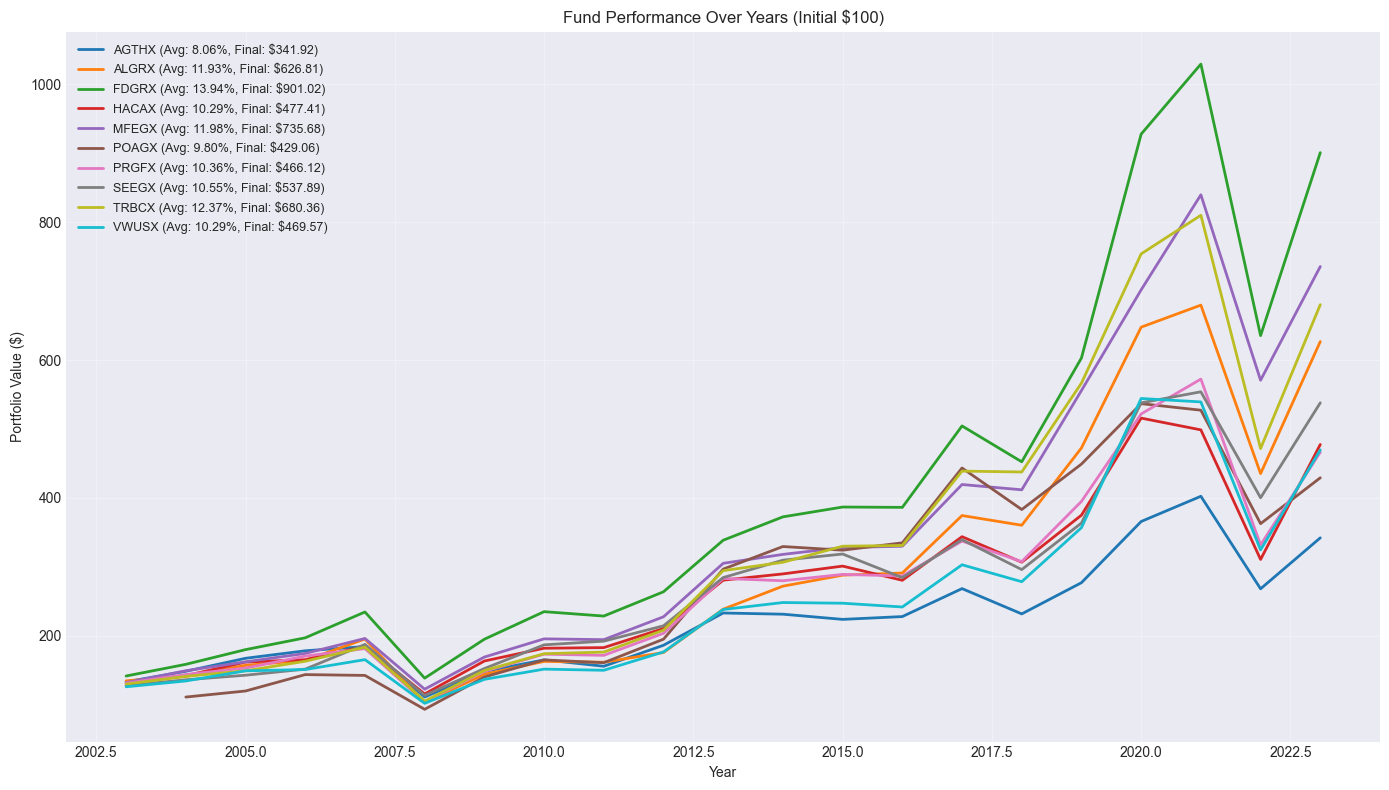

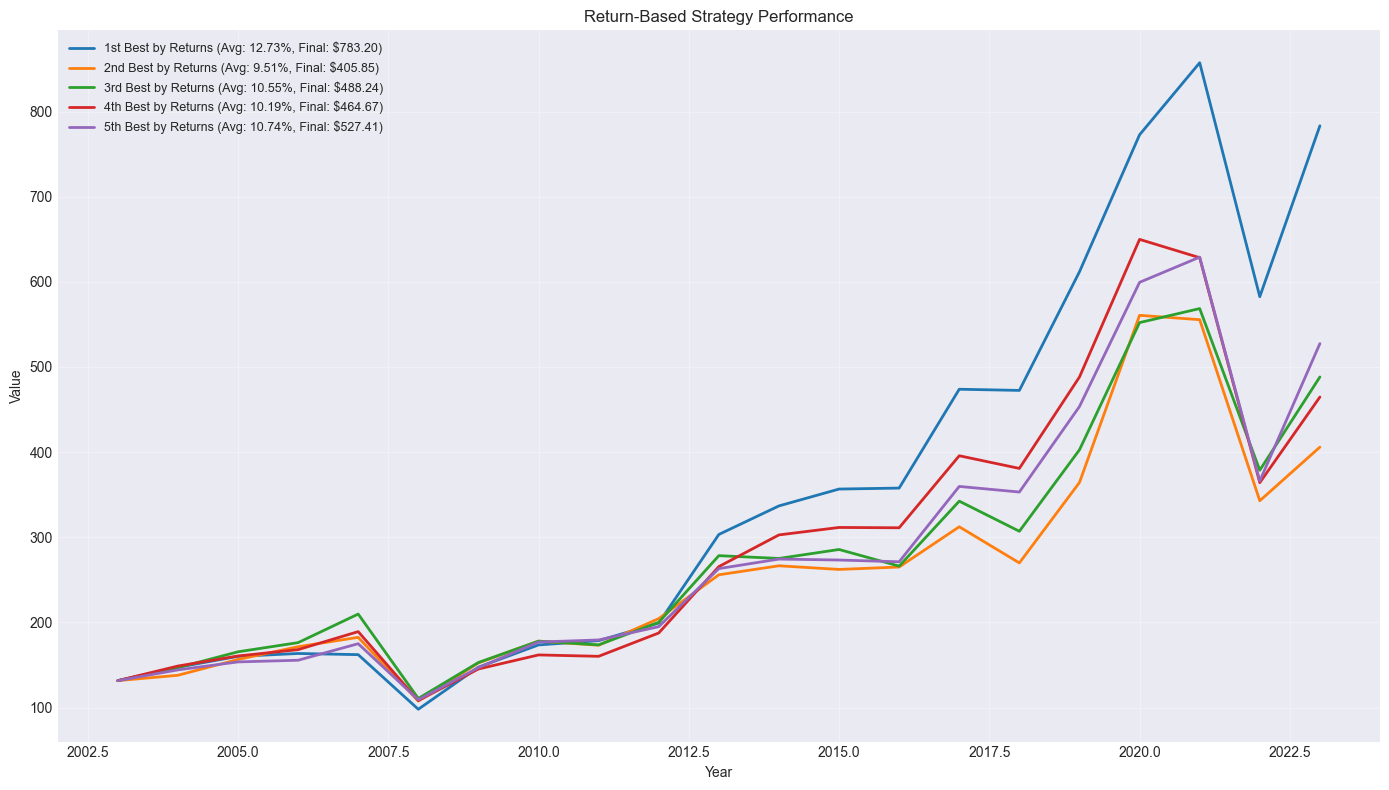

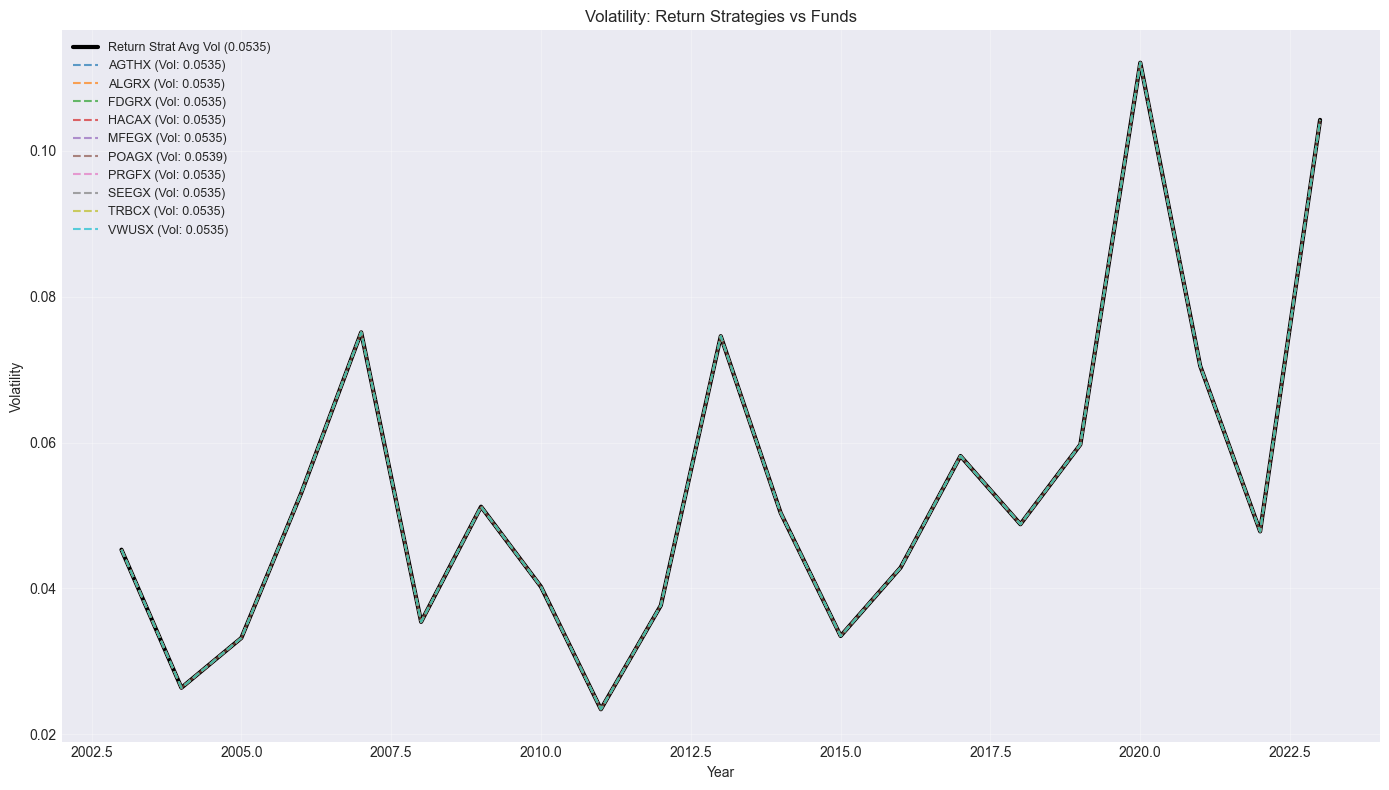

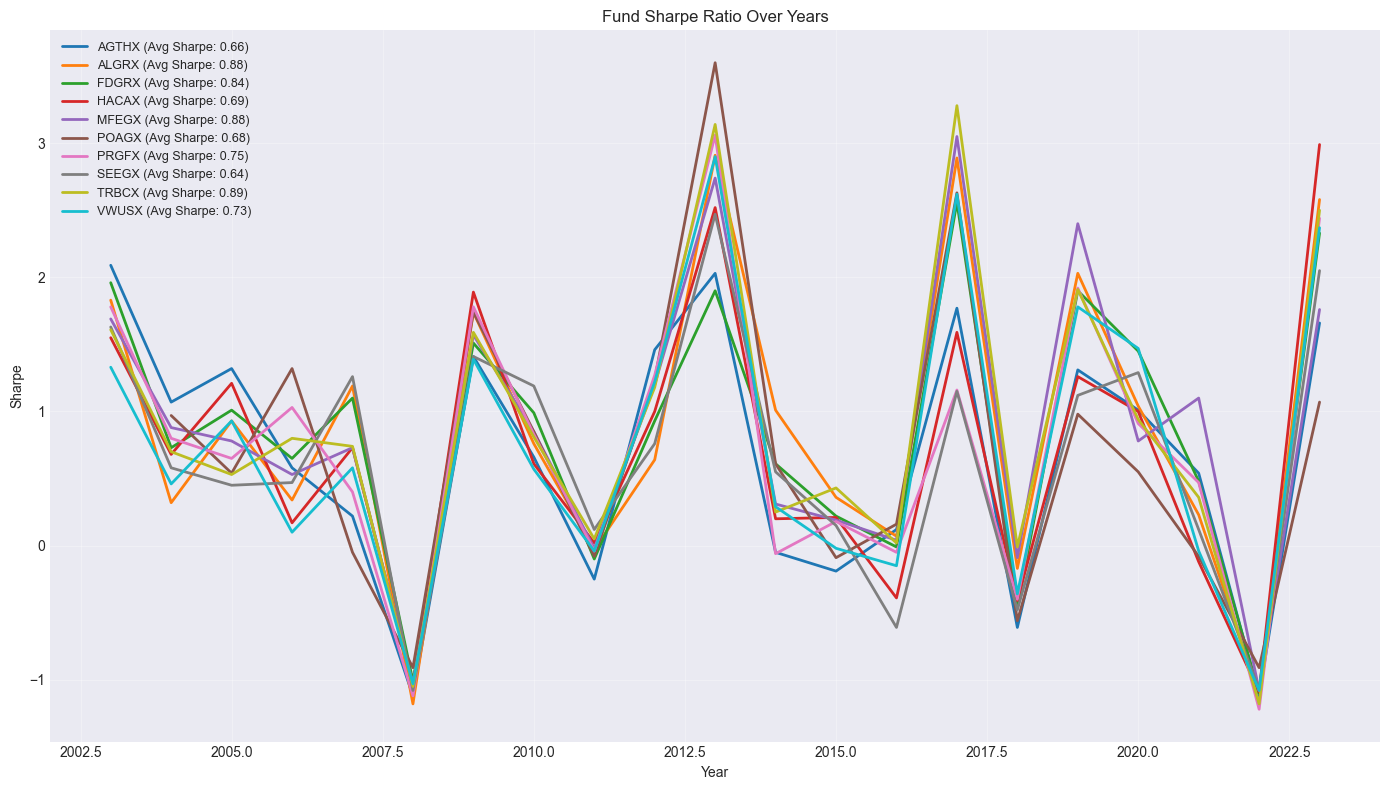

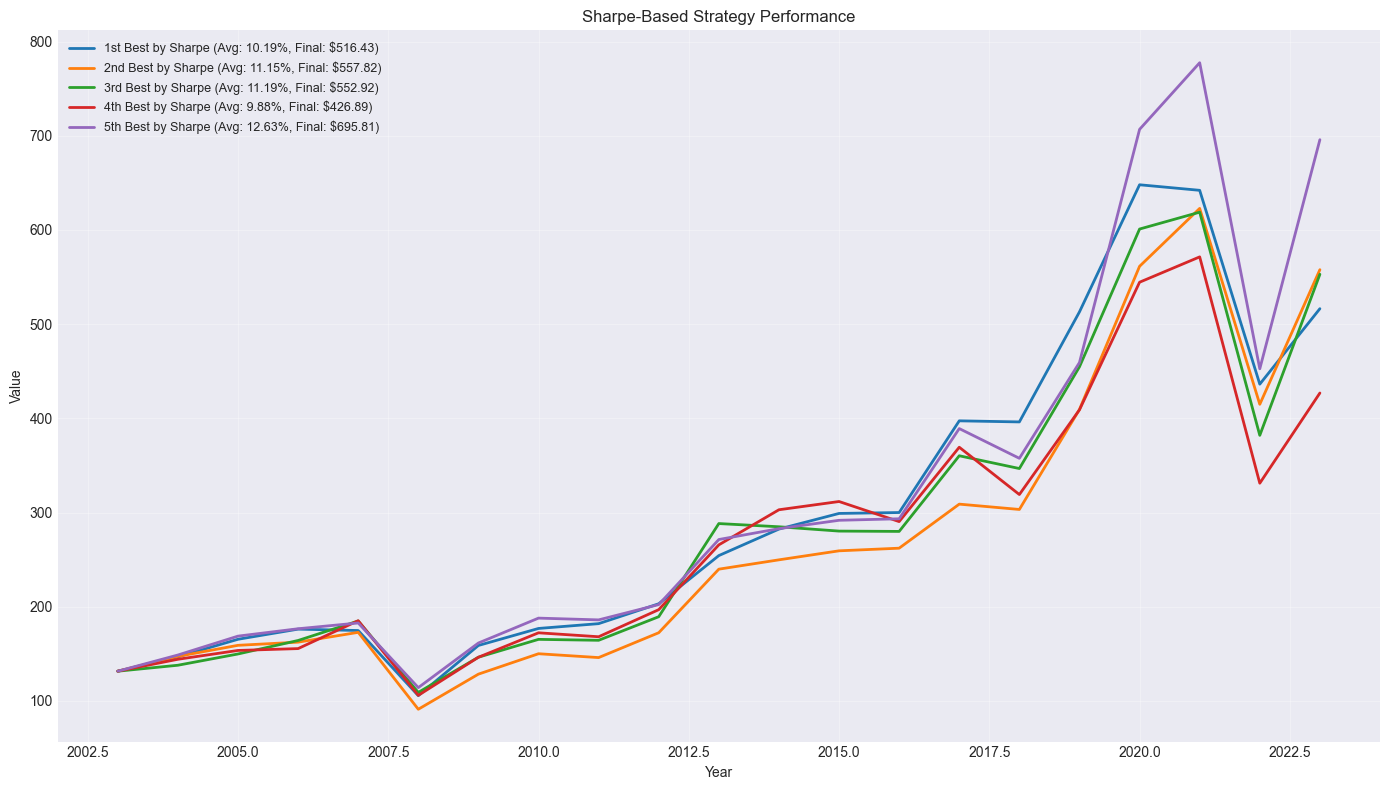

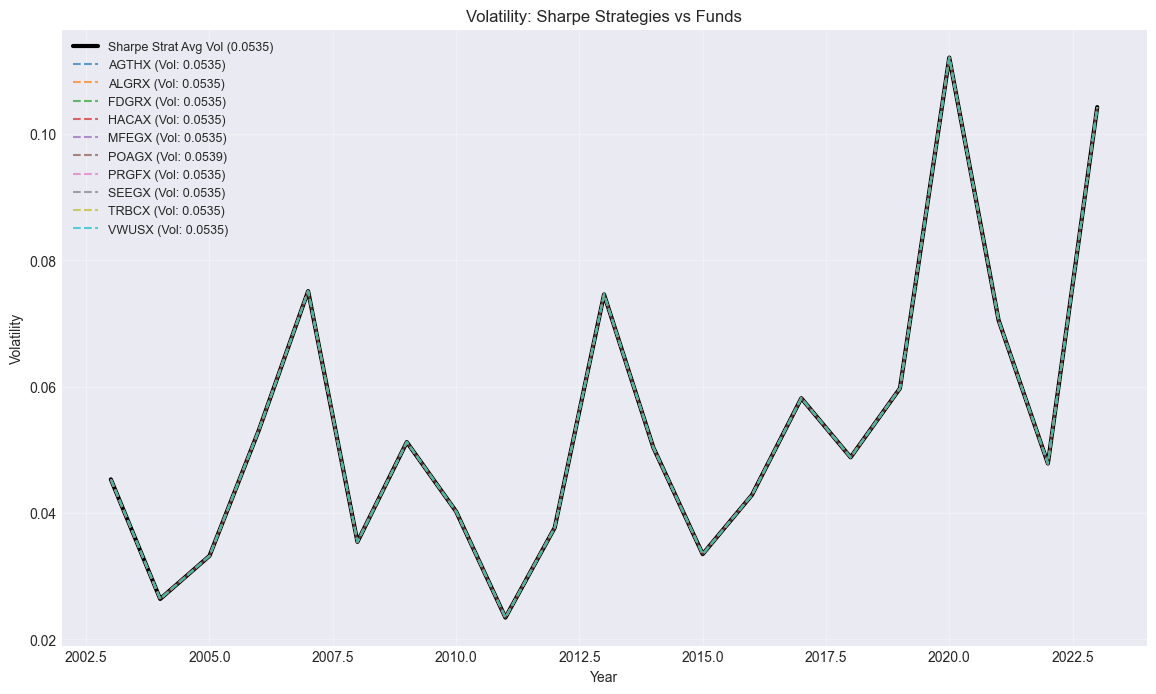

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to convert string percentages to float values
def convert_percentage(x):
    if isinstance(x, str) and '%' in x:
        return float(x.strip('%')) / 100
    return float(x)

# === START: Use df_calc directly instead of random generation ===
# Copy original DataFrame and convert columns
df_calc = df.copy()
df_calc['Annual_Return_Float'] = df_calc['Annual_Return'].apply(convert_percentage)
df_calc['Sharpe_Ratio'] = df_calc['Sharpe_Ratio'].astype(float)
# Prepare years and funds list for loops
df_extended = df_calc.copy()
years = sorted(df_extended['Year'].unique())
funds = sorted(df_extended['Fund'].unique())
# === END: Starting part replaced ===

# Calculate ranks for each year
df_extended = df_extended.assign(
    Return_Rank=df_extended.groupby('Year')['Annual_Return_Float']
                         .rank(ascending=False, method='first'),
    Sharpe_Rank=df_extended.groupby('Year')['Sharpe_Ratio']
                         .rank(ascending=False, method='first')
)

# Print first few rows to verify data format
print(df_extended.head())

# Function to implement strategy based on rank

def implement_strategy(data, start_amount=100, rank_column='Return_Rank', target_rank=1):
    """
    Invest in the fund with `target_rank` from the previous year by `rank_column`.
    """
    yrs = sorted(data['Year'].unique())
    perf = []
    amt = start_amount
    label = f"{target_rank}{'st' if target_rank==1 else 'nd' if target_rank==2 else 'rd' if target_rank==3 else 'th'} Best by {'Returns' if rank_column=='Return_Rank' else 'Sharpe'}"

    # First year: equal-weighted
    first = yrs[0]
    r0 = data.loc[data['Year']==first, 'Annual_Return_Float'].mean()
    amt *= (1 + r0)
    perf.append({'Year': first, 'Strategy': label, 'Amount': amt,
                 'Return': r0, 'Volatility': data.loc[data['Year']==first, 'Annual_Return_Float'].std()})

    for i in range(1, len(yrs)):
        yr = yrs[i]
        prev = yrs[i-1]
        ranked = data.loc[data['Year']==prev].sort_values(rank_column)
        if len(ranked) >= target_rank:
            f = ranked.iloc[target_rank-1]['Fund']
            row = data[(data['Year']==yr) & (data['Fund']==f)]
            if not row.empty:
                ret = row['Annual_Return_Float'].iloc[0]
                amt *= (1 + ret)
            else:
                ret = 0
        else:
            ret = 0
        vol = data.loc[data['Year']==yr, 'Annual_Return_Float'].std()
        perf.append({'Year': yr, 'Strategy': label, 'Amount': amt,
                     'Return': ret, 'Volatility': vol})
    return pd.DataFrame(perf)

# Run return-based strategies
return_strategies = [implement_strategy(df_extended, 100, 'Return_Rank', r) for r in range(1, 6)]
return_strategy_df = pd.concat(return_strategies)

# Run Sharpe-based strategies
sharpe_strategies = [implement_strategy(df_extended, 100, 'Sharpe_Rank', r) for r in range(1, 6)]
sharpe_strategy_df = pd.concat(sharpe_strategies)

# Individual fund performance
fund_perf = []
for fund in funds:
    df_f = df_extended[df_extended['Fund']==fund]
    val = 100
    for yr in years:
        row = df_f[df_f['Year']==yr]
        if not row.empty:
            r = row['Annual_Return_Float'].iloc[0]
            val *= (1 + r)
            vol = df_extended.loc[df_extended['Year']==yr, 'Annual_Return_Float'].std()
            fund_perf.append({'Year': yr, 'Fund': fund, 'Amount': val,
                              'Return': r, 'Volatility': vol})
fund_performance_df = pd.DataFrame(fund_perf)

# Compute summary metrics
fund_avg_returns = fund_performance_df.groupby('Fund')['Return'].mean()
fund_final_values = {
    fund: fund_performance_df[(fund_performance_df['Fund']==fund) & (fund_performance_df['Year']==years[-1])]['Amount'].values[0]
    for fund in funds if not fund_performance_df[(fund_performance_df['Fund']==fund) & (fund_performance_df['Year']==years[-1])].empty
}
return_strategy_avg_returns = return_strategy_df.groupby('Strategy')['Return'].mean()
fund_avg_sharpe = df_extended.groupby('Fund')['Sharpe_Ratio'].mean()

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Fund performance plot
plt.figure(figsize=(14, 8))
for fund in funds:
    fp = fund_performance_df[fund_performance_df['Fund']==fund]
    avg_r = fund_avg_returns[fund]
    fv = fund_final_values.get(fund, 0)
    lbl = f"{fund} (Avg: {avg_r*100:.2f}%, Final: ${fv:.2f})"
    plt.plot(fp['Year'], fp['Amount'], label=lbl, linewidth=2)
plt.title('Fund Performance Over Years (Initial $100)')
plt.xlabel('Year')
plt.ylabel('Portfolio Value ($)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 2. Return strategies plot
plt.figure(figsize=(14, 8))
for strat in return_strategy_df['Strategy'].unique():
    sd = return_strategy_df[return_strategy_df['Strategy']==strat]
    avg_r = return_strategy_avg_returns[strat]
    fv = sd[sd['Year']==years[-1]]['Amount'].iloc[0]
    lbl = f"{strat} (Avg: {avg_r*100:.2f}%, Final: ${fv:.2f})"
    plt.plot(sd['Year'], sd['Amount'], label=lbl, linewidth=2)
plt.title('Return-Based Strategy Performance')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 3. Volatility comparison (returns)
plt.figure(figsize=(14, 8))
ret_vol = return_strategy_df.groupby('Year')['Volatility'].mean()
avg_ret_vol = ret_vol.mean()
plt.plot(ret_vol.index, ret_vol.values, label=f'Return Strat Avg Vol ({avg_ret_vol:.4f})', linewidth=3, color='black')
fund_avg_vol = fund_performance_df.groupby('Fund')['Volatility'].mean()
for fund in funds:
    fdf = fund_performance_df[fund_performance_df['Fund']==fund]
    v = fund_avg_vol[fund]
    plt.plot(fdf['Year'], fdf['Volatility'], label=f"{fund} (Vol: {v:.4f})", linestyle='--', alpha=0.7)
plt.title('Volatility: Return Strategies vs Funds')
plt.xlabel('Year')
plt.ylabel('Volatility')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 4. Sharpe ratio over years
plt.figure(figsize=(14, 8))
for fund in funds:
    fdf = df_extended[df_extended['Fund']==fund]
    avg_s = fund_avg_sharpe[fund]
    plt.plot(fdf['Year'], fdf['Sharpe_Ratio'], label=f"{fund} (Avg Sharpe: {avg_s:.2f})", linewidth=2)
plt.title('Fund Sharpe Ratio Over Years')
plt.xlabel('Year')
plt.ylabel('Sharpe')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 5. Sharpe strategies plot
plt.figure(figsize=(14, 8))
sh_avg_ret = sharpe_strategy_df.groupby('Strategy')['Return'].mean()
for strat in sharpe_strategy_df['Strategy'].unique():
    sd = sharpe_strategy_df[sharpe_strategy_df['Strategy']==strat]
    avg_r = sh_avg_ret[strat]
    fv = sd[sd['Year']==years[-1]]['Amount'].iloc[0]
    lbl = f"{strat} (Avg: {avg_r*100:.2f}%, Final: ${fv:.2f})"
    plt.plot(sd['Year'], sd['Amount'], label=lbl, linewidth=2)
plt.title('Sharpe-Based Strategy Performance')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 6. Volatility comparison (Sharpe)
plt.figure(figsize=(14, 8))
sh_vol = sharpe_strategy_df.groupby('Year')['Volatility'].mean()
avg_sh_vol = sh_vol.mean()
plt.plot(sh_vol.index, sh_vol.values, label=f"Sharpe Strat Avg Vol ({avg_sh_vol:.4f})", linewidth=3, color='black')
for fund in funds:
    fdf = fund_performance_df[fund_performance_df['Fund']==fund]
    v = fund_avg_vol[fund]
    plt.plot(fdf['Year'], fdf['Volatility'], label=f"{fund} (Vol: {v:.4f})", linestyle='--', alpha=0.7)
plt.title('Volatility: Sharpe Strategies vs Funds')
plt.xlabel('Year')
plt.ylabel('Volatility')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)


In [4]:
# === Create Final Summary Table ===

# 1) Select only the first 10 funds
funds_to_show = funds[:10]

# 2) Pivot Fund Performance: one column per fund’s final Amount
fund_pivot = (
    fund_performance_df
      .pivot(index='Year', columns='Fund', values='Amount')
      .loc[:, funds_to_show]                     # keep only first 10 funds
      .reset_index()
)

# 3) Pivot Return-based Strategies (1st–5th best by Returns)
#    we know those Strategies all contain "Best by Returns"
return_pivot = (
    return_strategy_df
      .pivot(index='Year', columns='Strategy', values='Amount')
      .filter(like='Best by Returns')           # pick only the 5 return-based strategies
      .reset_index()
)

# 4) Merge Funds and Return-strategies on Year
final_table = fund_pivot.merge(return_pivot, on='Year', how='left')

# 5) Rename the strategy columns to "1st Best Strategy" … "5th Best Strategy"
strat_cols = [c for c in final_table.columns if 'Best by Returns' in c]
new_names = {}
for i, col in enumerate(sorted(strat_cols), start=1):
    suffix = 'st' if i==1 else 'nd' if i==2 else 'rd' if i==3 else 'th'
    new_names[col] = f"{i}{suffix} Best Strategy"
final_table.rename(columns=new_names, inplace=True)

# 6) Show the result
print(final_table)

    Year       AGTHX       ALGRX        FDGRX       HACAX       MFEGX  \
0   2003  132.860000  134.370000   141.360000  130.230000  131.790000   
1   2004  148.231902  140.819760   158.294928  141.859539  148.988595   
2   2005  167.072177  156.816885   179.633084  161.606387  161.905906   
3   2006  177.948575  164.093188   196.806007  165.016282  174.113612   
4   2007  184.123391  195.008345   234.277871  184.603714  195.842990   
5   2008  110.879106  102.866902   138.223944  115.285020  122.186442   
6   2009  147.968167  143.921082   194.743714  163.128303  168.849444   
7   2010  164.806944  162.544471   234.744073  181.675991  195.274382   
8   2011  155.544794  161.357896   228.359035  182.566203  194.102735   
9   2012  185.969356  175.444440   263.617670  210.371036  227.294303   
10  2013  232.796440  238.341272   338.432364  280.487702  304.915308   
11  2014  231.073746  271.756718   372.343287  289.547455  317.874208   
12  2015  223.540742  287.736013   386.604035  300.

## For Index Funds

In [5]:
import pandas as pd
df1=pd.read_csv("mutual_fund_index_1.csv")
df2=pd.read_csv("mutual_fund_index_2.csv")
df=pd.concat([df1, df2], ignore_index=True)
df=df.drop(columns=['Return_Rank','Sharpe_Rank'], axis=1)

   Year   Fund Annual_Return  Sharpe_Ratio  Annual_Return_Float  Return_Rank  \
0  2003  DFUSX        26.45%          1.55               0.2645          6.0   
1  2003  SWPPX        26.70%          1.56               0.2670          2.0   
2  2003  VFIAX        26.53%          1.55               0.2653          3.0   
3  2003  VIIIX        26.51%          1.55               0.2651          4.0   
4  2003  VINIX        26.51%          1.55               0.2651          5.0   

   Sharpe_Rank  
0          3.0  
1          2.0  
2          4.0  
3          5.0  
4          6.0  


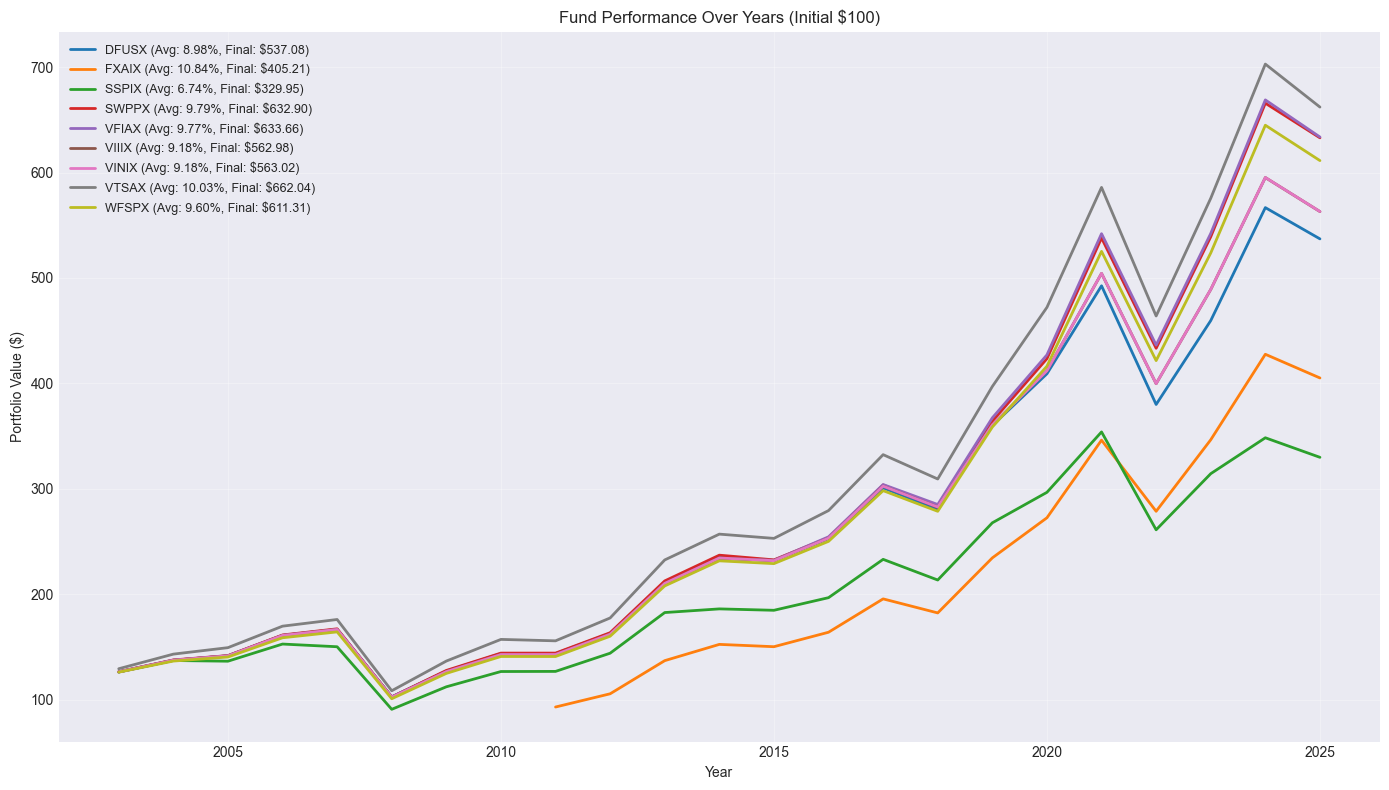

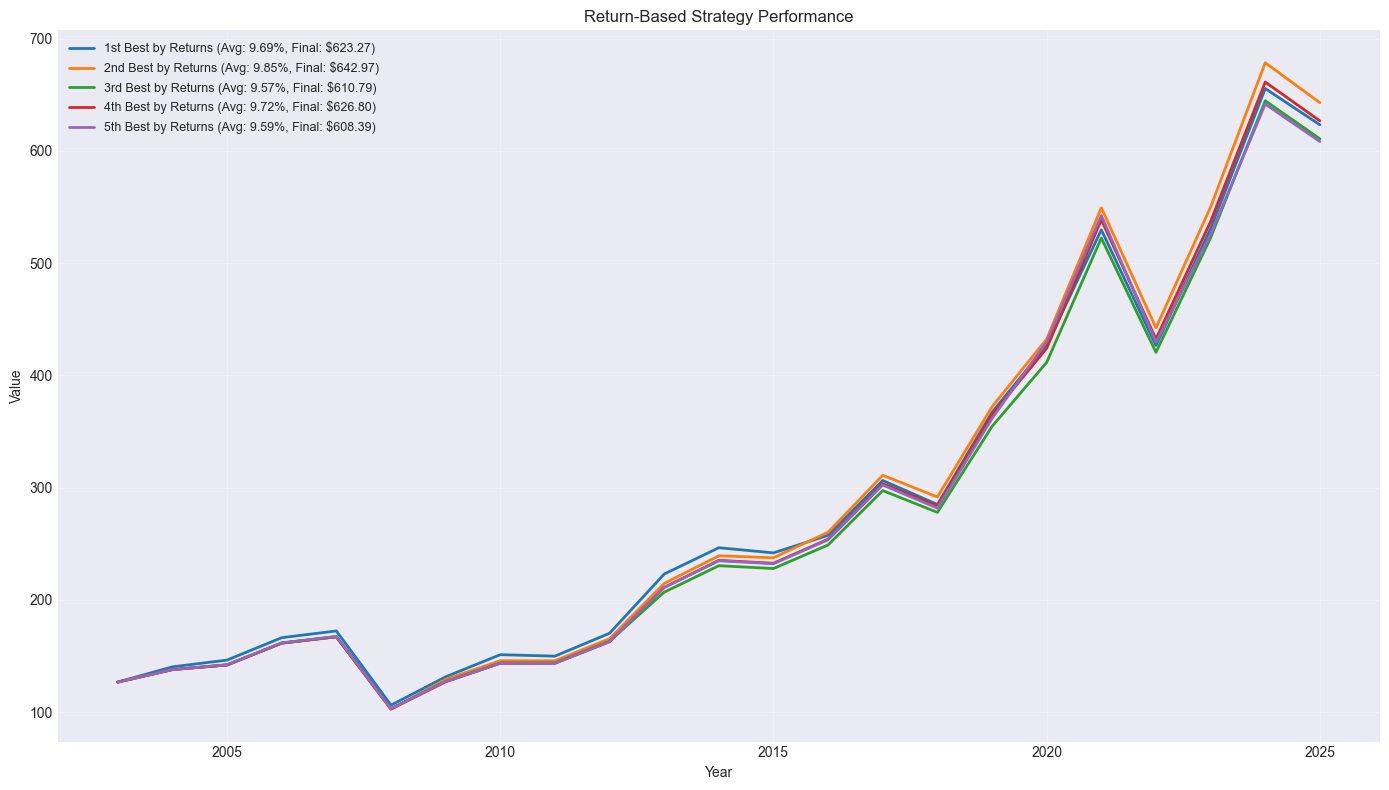

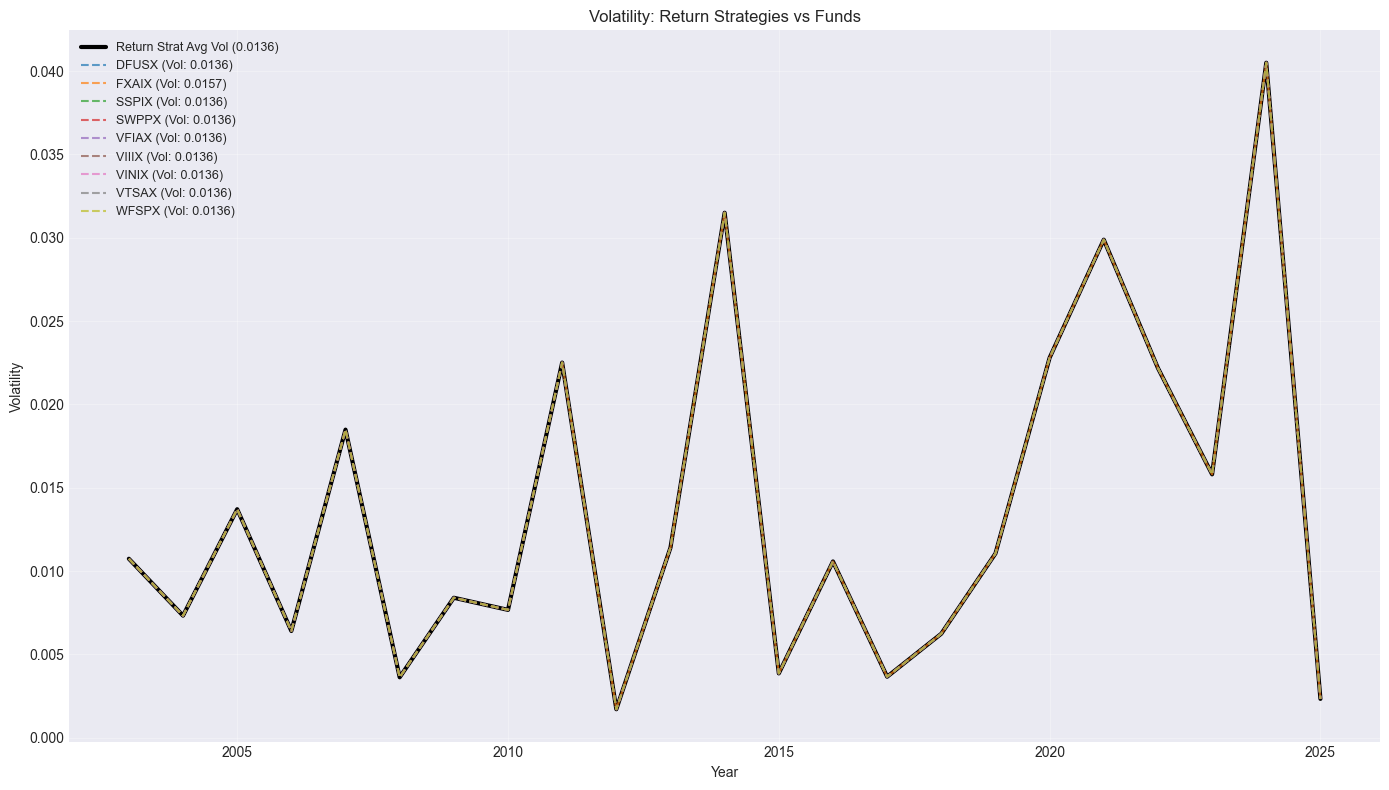

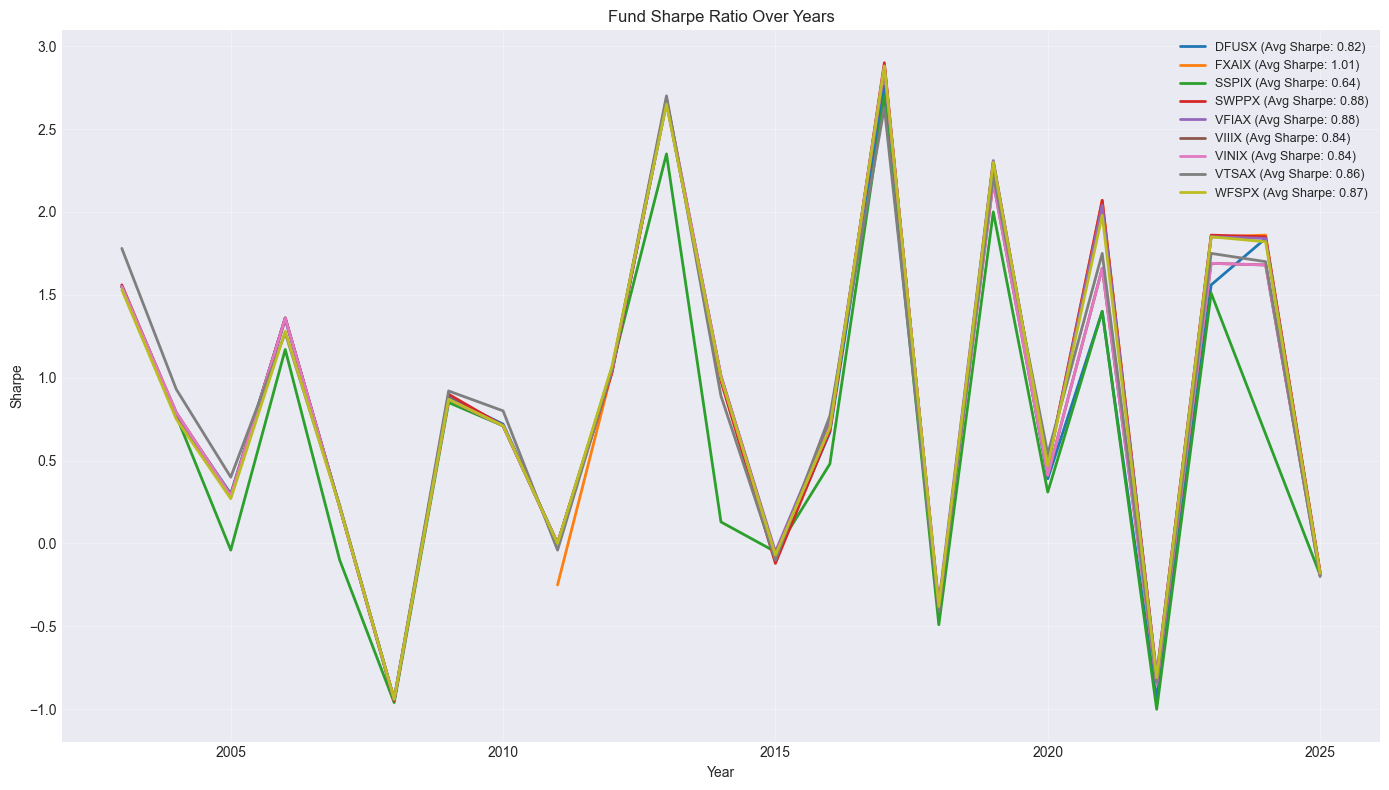

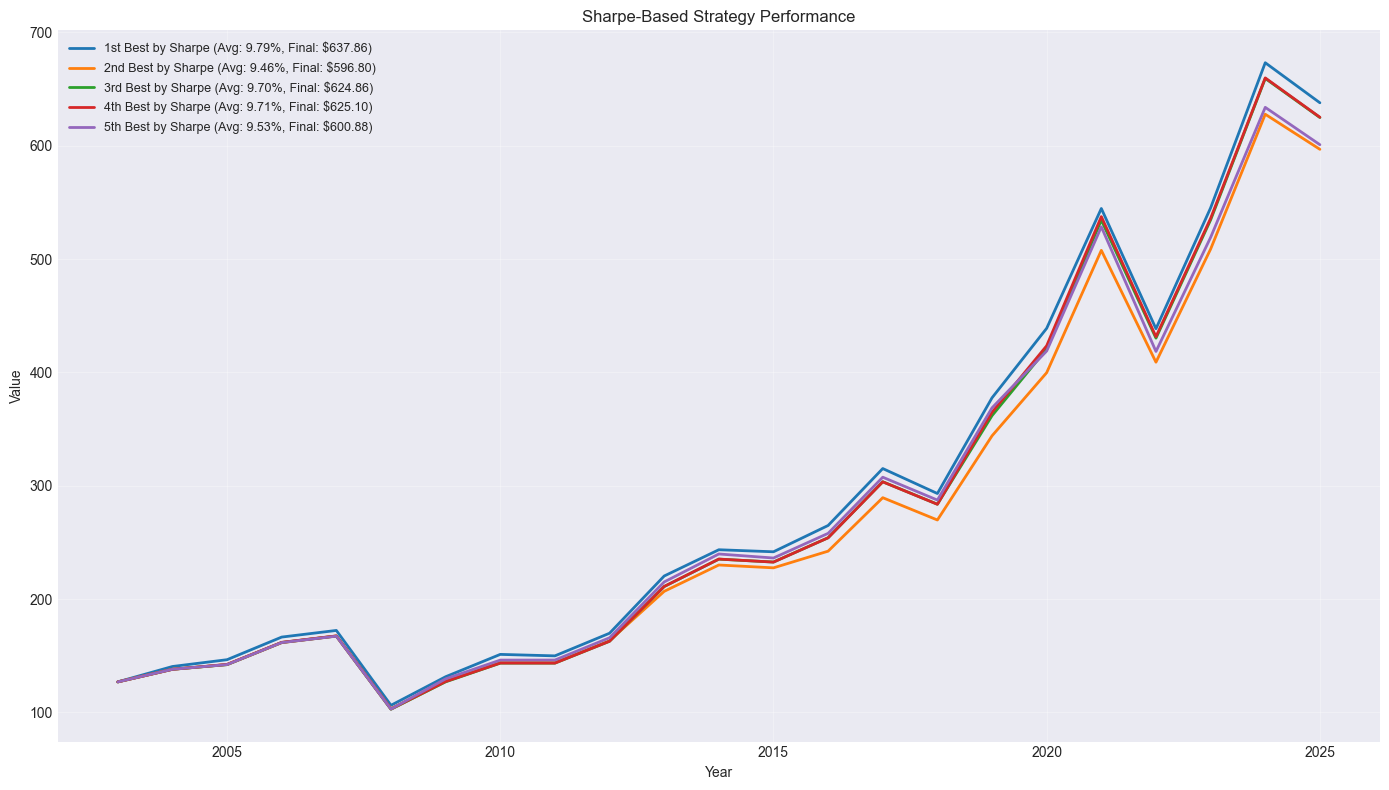

    Year       DFUSX       FXAIX       SSPIX       SWPPX       VFIAX  \
0   2003  126.450000         NaN  126.410000  126.700000  126.530000   
1   2004  137.501730         NaN  137.306542  137.836930  137.576069   
2   2005  141.860535         NaN  136.647471  141.972038  141.620805   
3   2006  161.196126         NaN  152.908520  161.521588  160.937883   
4   2007  166.870229         NaN  150.354947  167.352517  166.554615   
5   2008  102.908870         NaN   91.024885  102.737710  102.397778   
6   2009  127.329145         NaN  112.379323  127.887902  126.522694   
7   2010  143.894667         NaN  126.865018  144.334286  142.742903   
8   2011  143.894667   93.210000  126.979196  144.334286  142.700080   
9   2012  163.075826  105.756066  144.235669  163.660646  161.893241   
10  2013  211.623500  137.176193  182.775440  212.775207  209.943155   
11  2014  235.748579  152.594797  186.248173  237.180523  234.002641   
12  2015  232.259500  150.397432  184.925811  232.745247  232.27

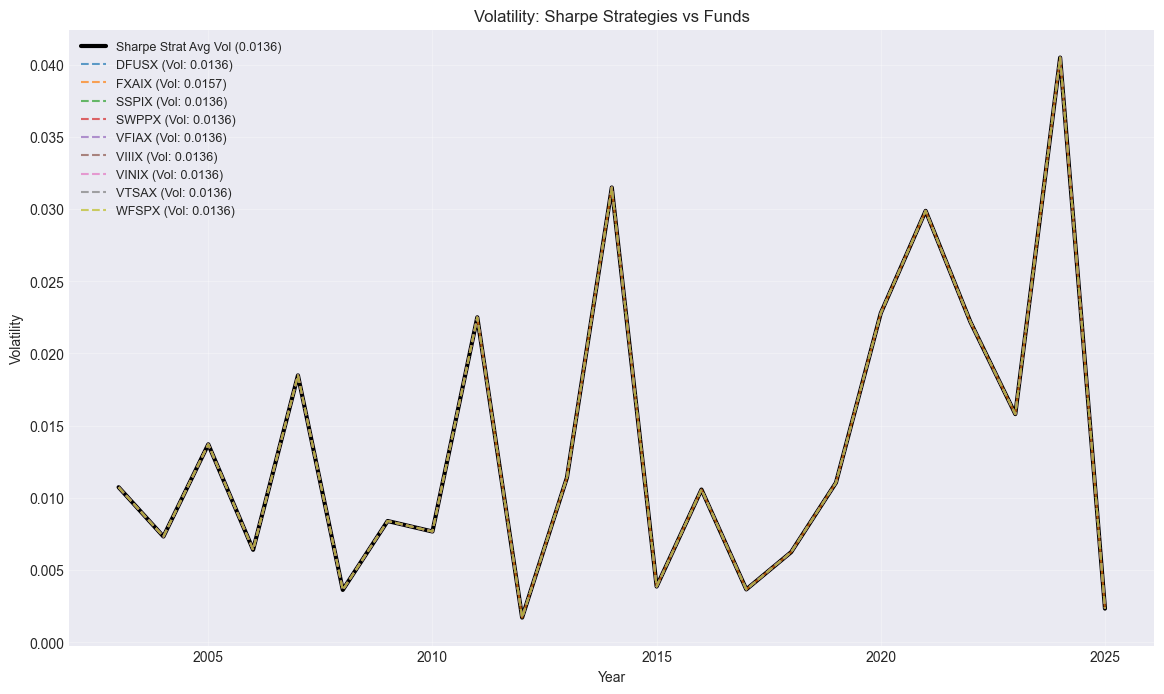

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to convert string percentages to float values
def convert_percentage(x):
    if isinstance(x, str) and '%' in x:
        return float(x.strip('%')) / 100
    return float(x)

# === START: Use df_calc directly instead of random generation ===
# Copy original DataFrame and convert columns
df_calc = df.copy()
df_calc['Annual_Return_Float'] = df_calc['Annual_Return'].apply(convert_percentage)
df_calc['Sharpe_Ratio'] = df_calc['Sharpe_Ratio'].astype(float)
# Prepare years and funds list for loops
df_extended = df_calc.copy()
years = sorted(df_extended['Year'].unique())
funds = sorted(df_extended['Fund'].unique())
# === END: Starting part replaced ===

# Calculate ranks for each year
df_extended = df_extended.assign(
    Return_Rank=df_extended.groupby('Year')['Annual_Return_Float']
                         .rank(ascending=False, method='first'),
    Sharpe_Rank=df_extended.groupby('Year')['Sharpe_Ratio']
                         .rank(ascending=False, method='first')
)

# Print first few rows to verify data format
print(df_extended.head())

# Function to implement strategy based on rank

def implement_strategy(data, start_amount=100, rank_column='Return_Rank', target_rank=1):
    """
    Invest in the fund with `target_rank` from the previous year by `rank_column`.
    """
    yrs = sorted(data['Year'].unique())
    perf = []
    amt = start_amount
    label = f"{target_rank}{'st' if target_rank==1 else 'nd' if target_rank==2 else 'rd' if target_rank==3 else 'th'} Best by {'Returns' if rank_column=='Return_Rank' else 'Sharpe'}"

    # First year: equal-weighted
    first = yrs[0]
    r0 = data.loc[data['Year']==first, 'Annual_Return_Float'].mean()
    amt *= (1 + r0)
    perf.append({'Year': first, 'Strategy': label, 'Amount': amt,
                 'Return': r0, 'Volatility': data.loc[data['Year']==first, 'Annual_Return_Float'].std()})

    for i in range(1, len(yrs)):
        yr = yrs[i]
        prev = yrs[i-1]
        ranked = data.loc[data['Year']==prev].sort_values(rank_column)
        if len(ranked) >= target_rank:
            f = ranked.iloc[target_rank-1]['Fund']
            row = data[(data['Year']==yr) & (data['Fund']==f)]
            if not row.empty:
                ret = row['Annual_Return_Float'].iloc[0]
                amt *= (1 + ret)
            else:
                ret = 0
        else:
            ret = 0
        vol = data.loc[data['Year']==yr, 'Annual_Return_Float'].std()
        perf.append({'Year': yr, 'Strategy': label, 'Amount': amt,
                     'Return': ret, 'Volatility': vol})
    return pd.DataFrame(perf)

# Run return-based strategies
return_strategies = [implement_strategy(df_extended, 100, 'Return_Rank', r) for r in range(1, 6)]
return_strategy_df = pd.concat(return_strategies)

# Run Sharpe-based strategies
sharpe_strategies = [implement_strategy(df_extended, 100, 'Sharpe_Rank', r) for r in range(1, 6)]
sharpe_strategy_df = pd.concat(sharpe_strategies)

# Individual fund performance
fund_perf = []
for fund in funds:
    df_f = df_extended[df_extended['Fund']==fund]
    val = 100
    for yr in years:
        row = df_f[df_f['Year']==yr]
        if not row.empty:
            r = row['Annual_Return_Float'].iloc[0]
            val *= (1 + r)
            vol = df_extended.loc[df_extended['Year']==yr, 'Annual_Return_Float'].std()
            fund_perf.append({'Year': yr, 'Fund': fund, 'Amount': val,
                              'Return': r, 'Volatility': vol})
fund_performance_df = pd.DataFrame(fund_perf)

# Compute summary metrics
fund_avg_returns = fund_performance_df.groupby('Fund')['Return'].mean()
fund_final_values = {
    fund: fund_performance_df[(fund_performance_df['Fund']==fund) & (fund_performance_df['Year']==years[-1])]['Amount'].values[0]
    for fund in funds if not fund_performance_df[(fund_performance_df['Fund']==fund) & (fund_performance_df['Year']==years[-1])].empty
}
return_strategy_avg_returns = return_strategy_df.groupby('Strategy')['Return'].mean()
fund_avg_sharpe = df_extended.groupby('Fund')['Sharpe_Ratio'].mean()

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Fund performance plot
plt.figure(figsize=(14, 8))
for fund in funds:
    fp = fund_performance_df[fund_performance_df['Fund']==fund]
    avg_r = fund_avg_returns[fund]
    fv = fund_final_values.get(fund, 0)
    lbl = f"{fund} (Avg: {avg_r*100:.2f}%, Final: ${fv:.2f})"
    plt.plot(fp['Year'], fp['Amount'], label=lbl, linewidth=2)
plt.title('Fund Performance Over Years (Initial $100)')
plt.xlabel('Year')
plt.ylabel('Portfolio Value ($)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 2. Return strategies plot
plt.figure(figsize=(14, 8))
for strat in return_strategy_df['Strategy'].unique():
    sd = return_strategy_df[return_strategy_df['Strategy']==strat]
    avg_r = return_strategy_avg_returns[strat]
    fv = sd[sd['Year']==years[-1]]['Amount'].iloc[0]
    lbl = f"{strat} (Avg: {avg_r*100:.2f}%, Final: ${fv:.2f})"
    plt.plot(sd['Year'], sd['Amount'], label=lbl, linewidth=2)
plt.title('Return-Based Strategy Performance')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 3. Volatility comparison (returns)
plt.figure(figsize=(14, 8))
ret_vol = return_strategy_df.groupby('Year')['Volatility'].mean()
avg_ret_vol = ret_vol.mean()
plt.plot(ret_vol.index, ret_vol.values, label=f'Return Strat Avg Vol ({avg_ret_vol:.4f})', linewidth=3, color='black')
fund_avg_vol = fund_performance_df.groupby('Fund')['Volatility'].mean()
for fund in funds:
    fdf = fund_performance_df[fund_performance_df['Fund']==fund]
    v = fund_avg_vol[fund]
    plt.plot(fdf['Year'], fdf['Volatility'], label=f"{fund} (Vol: {v:.4f})", linestyle='--', alpha=0.7)
plt.title('Volatility: Return Strategies vs Funds')
plt.xlabel('Year')
plt.ylabel('Volatility')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 4. Sharpe ratio over years
plt.figure(figsize=(14, 8))
for fund in funds:
    fdf = df_extended[df_extended['Fund']==fund]
    avg_s = fund_avg_sharpe[fund]
    plt.plot(fdf['Year'], fdf['Sharpe_Ratio'], label=f"{fund} (Avg Sharpe: {avg_s:.2f})", linewidth=2)
plt.title('Fund Sharpe Ratio Over Years')
plt.xlabel('Year')
plt.ylabel('Sharpe')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 5. Sharpe strategies plot
plt.figure(figsize=(14, 8))
sh_avg_ret = sharpe_strategy_df.groupby('Strategy')['Return'].mean()
for strat in sharpe_strategy_df['Strategy'].unique():
    sd = sharpe_strategy_df[sharpe_strategy_df['Strategy']==strat]
    avg_r = sh_avg_ret[strat]
    fv = sd[sd['Year']==years[-1]]['Amount'].iloc[0]
    lbl = f"{strat} (Avg: {avg_r*100:.2f}%, Final: ${fv:.2f})"
    plt.plot(sd['Year'], sd['Amount'], label=lbl, linewidth=2)
plt.title('Sharpe-Based Strategy Performance')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 6. Volatility comparison (Sharpe)
plt.figure(figsize=(14, 8))
sh_vol = sharpe_strategy_df.groupby('Year')['Volatility'].mean()
avg_sh_vol = sh_vol.mean()
plt.plot(sh_vol.index, sh_vol.values, label=f"Sharpe Strat Avg Vol ({avg_sh_vol:.4f})", linewidth=3, color='black')
for fund in funds:
    fdf = fund_performance_df[fund_performance_df['Fund']==fund]
    v = fund_avg_vol[fund]
    plt.plot(fdf['Year'], fdf['Volatility'], label=f"{fund} (Vol: {v:.4f})", linestyle='--', alpha=0.7)
plt.title('Volatility: Sharpe Strategies vs Funds')
plt.xlabel('Year')
plt.ylabel('Volatility')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

# === Create Final Summary Table ===

# 1) Select only the first 10 funds
funds_to_show = funds[:10]

# 2) Pivot Fund Performance: one column per fund’s final Amount
fund_pivot = (
    fund_performance_df
      .pivot(index='Year', columns='Fund', values='Amount')
      .loc[:, funds_to_show]                     # keep only first 10 funds
      .reset_index()
)

# 3) Pivot Return-based Strategies (1st–5th best by Returns)
#    we know those Strategies all contain "Best by Returns"
return_pivot = (
    return_strategy_df
      .pivot(index='Year', columns='Strategy', values='Amount')
      .filter(like='Best by Returns')           # pick only the 5 return-based strategies
      .reset_index()
)

# 4) Merge Funds and Return-strategies on Year
final_table = fund_pivot.merge(return_pivot, on='Year', how='left')

# 5) Rename the strategy columns to "1st Best Strategy" … "5th Best Strategy"
strat_cols = [c for c in final_table.columns if 'Best by Returns' in c]
new_names = {}
for i, col in enumerate(sorted(strat_cols), start=1):
    suffix = 'st' if i==1 else 'nd' if i==2 else 'rd' if i==3 else 'th'
    new_names[col] = f"{i}{suffix} Best Strategy"
final_table.rename(columns=new_names, inplace=True)

# 6) Show the result
print(final_table)


## For income funds

In [7]:
import pandas as pd
df1=pd.read_csv("mutual_fund_income_1.csv")
df2=pd.read_csv("mutual_fund_income_2.csv")
df=pd.concat([df1, df2], ignore_index=True)
df=df.drop(columns=['Return_Rank','Sharpe_Rank'], axis=1)

In [8]:
df

,Year,Fund,Annual_Return,Sharpe_Ratio
0,2003,FAGIX,28.34%,5.67
1,2003,HCAIX,29.89%,1.54
2,2003,PTTRX,0.37%,0.08
3,2003,TIBAX,27.33%,3.18
4,2004,FAGIX,5.09%,1.40
...,...,...,...,...
179,2024,VWINX,-0.72%,-0.09
180,2025,AGTHX,-4.70%,-0.15
181,2025,DODIX,2.10%,0.33
182,2025,PRFDX,-0.87%,-0.04


   Year   Fund Annual_Return  Sharpe_Ratio  Annual_Return_Float  Return_Rank  \
0  2003  FAGIX        28.34%          5.67               0.2834          3.0   
1  2003  HCAIX        29.89%          1.54               0.2989          2.0   
2  2003  PTTRX         0.37%          0.08               0.0037          8.0   
3  2003  TIBAX        27.33%          3.18               0.2733          4.0   
4  2004  FAGIX         5.09%          1.40               0.0509          5.0   

   Sharpe_Rank  
0          1.0  
1          4.0  
2          8.0  
3          2.0  
4          2.0  


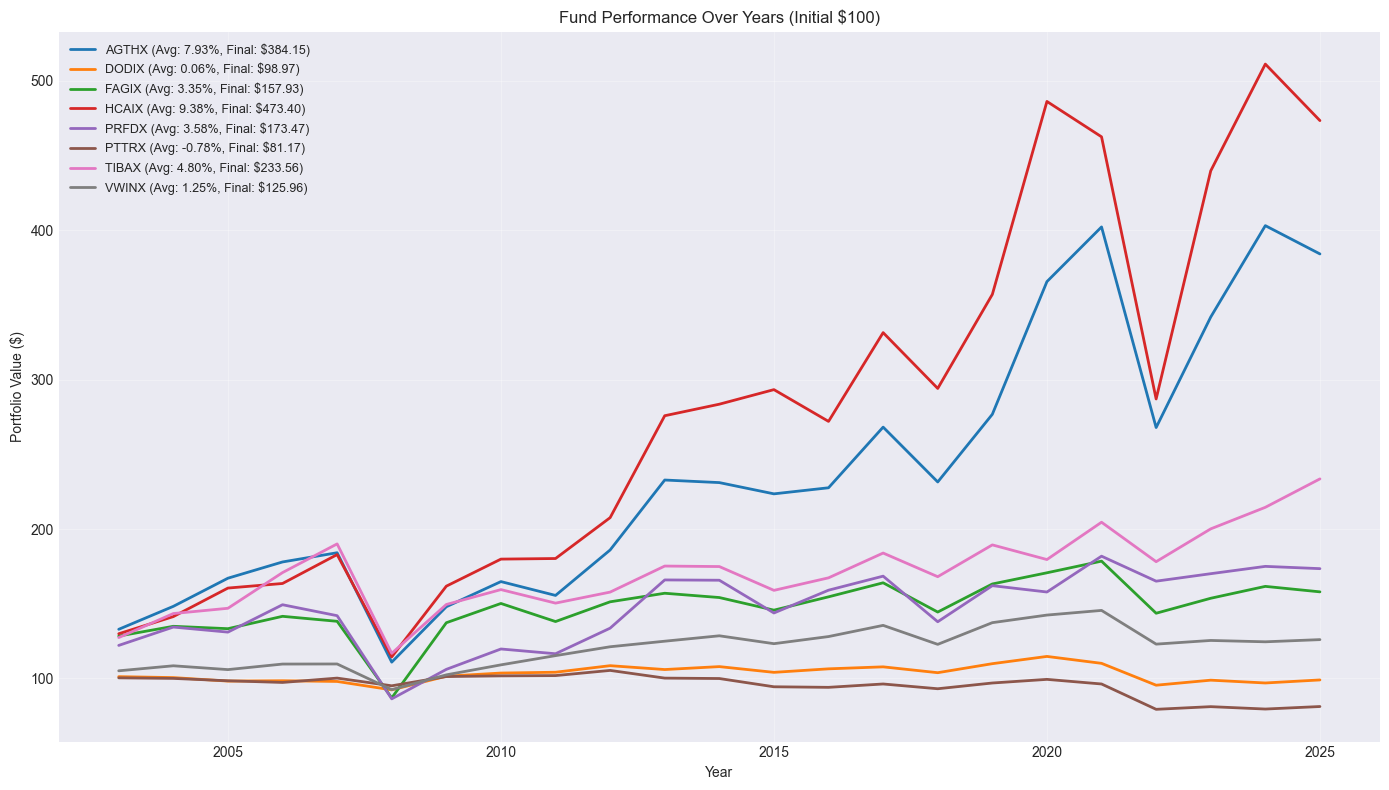

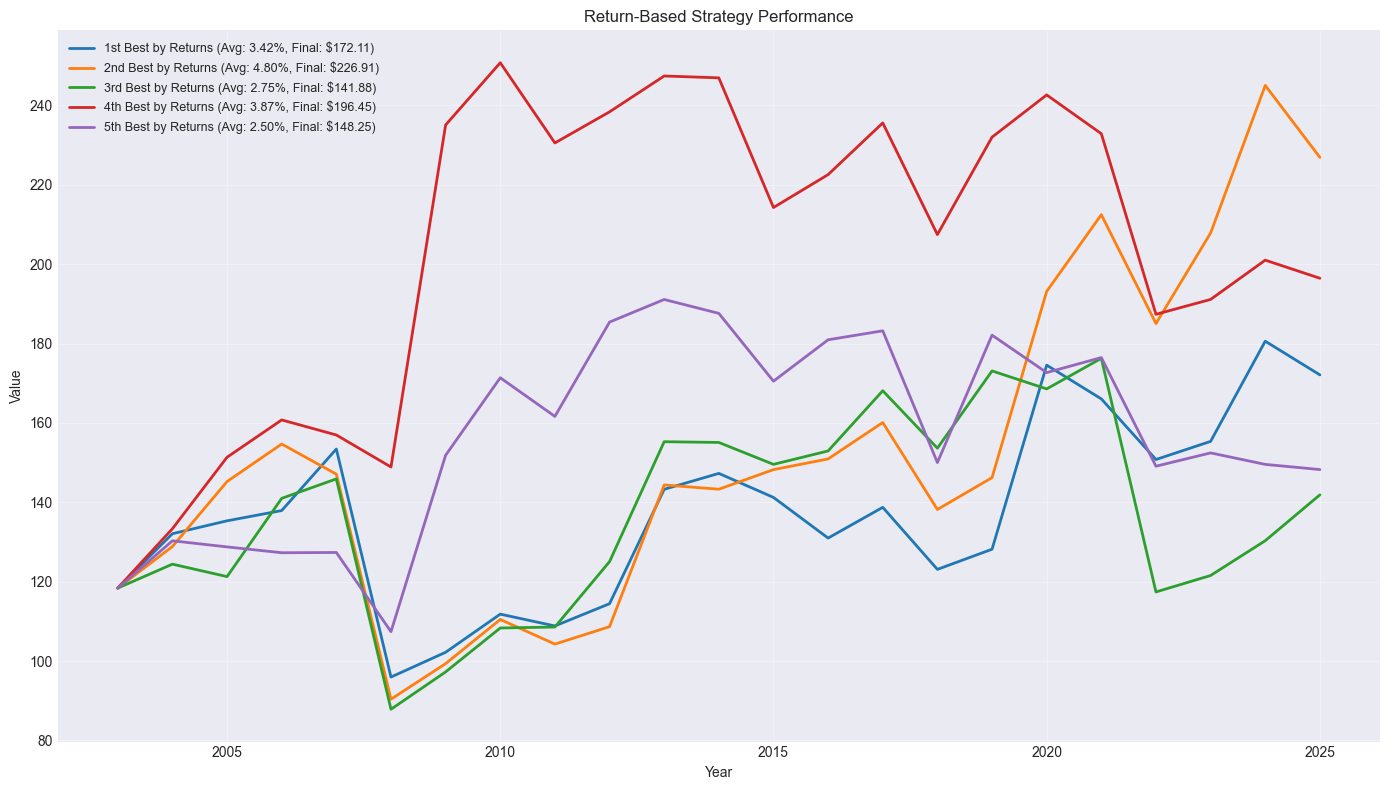

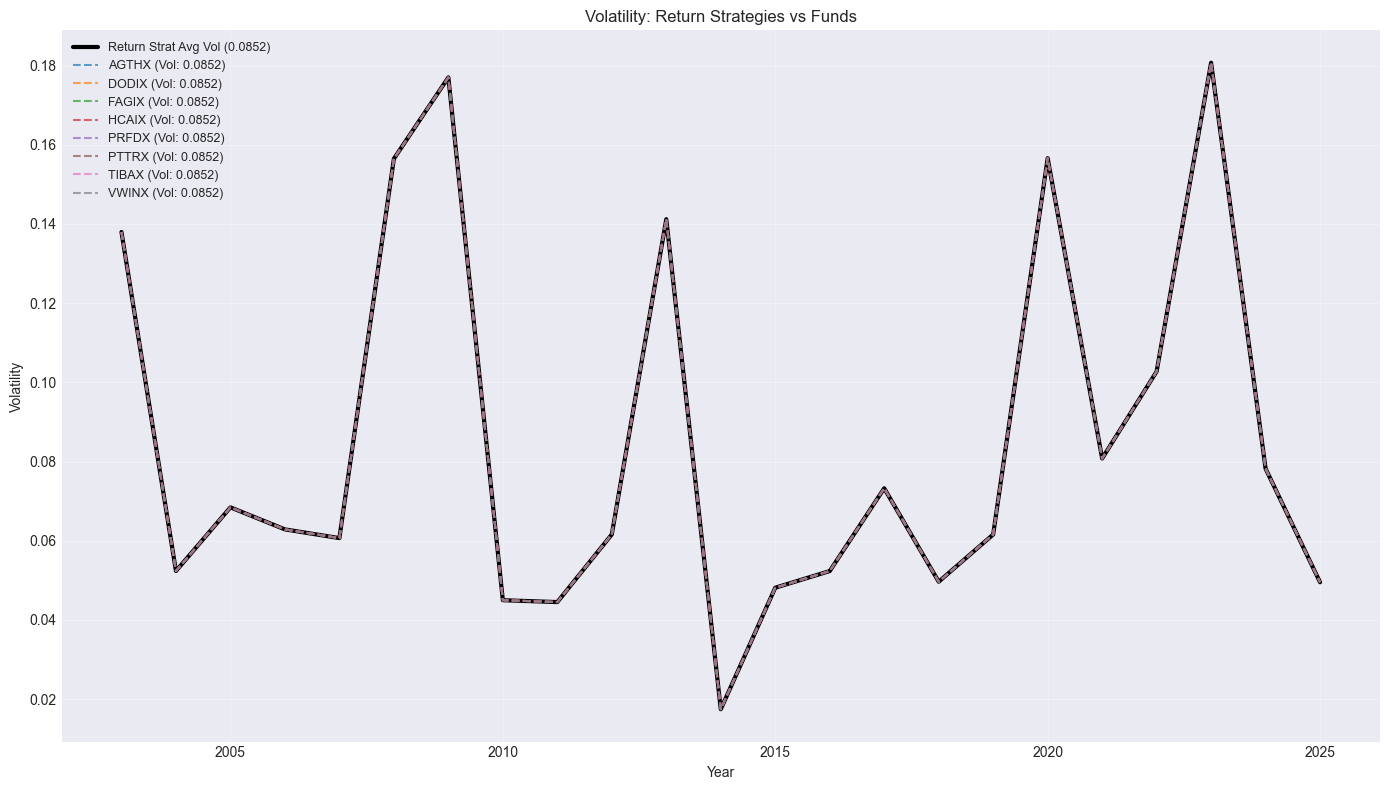

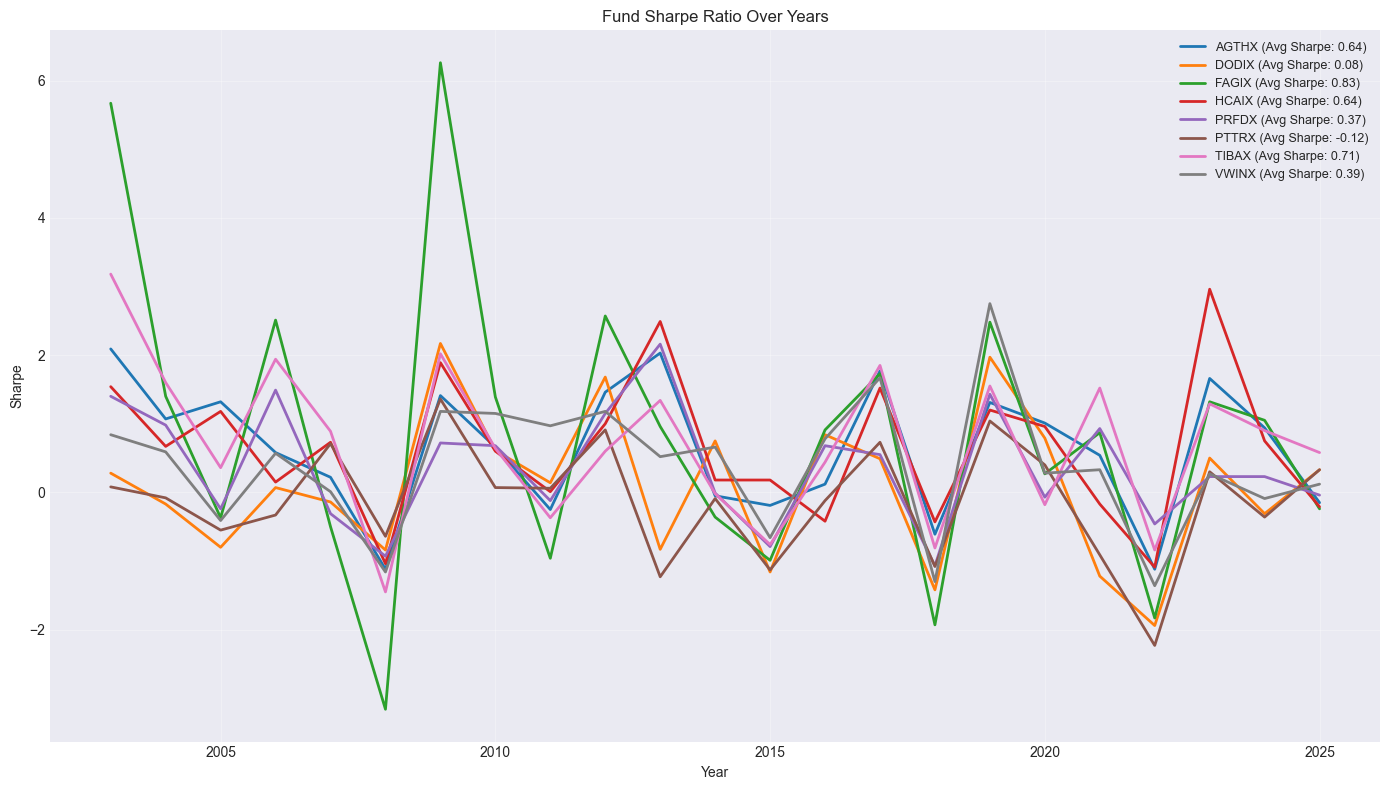

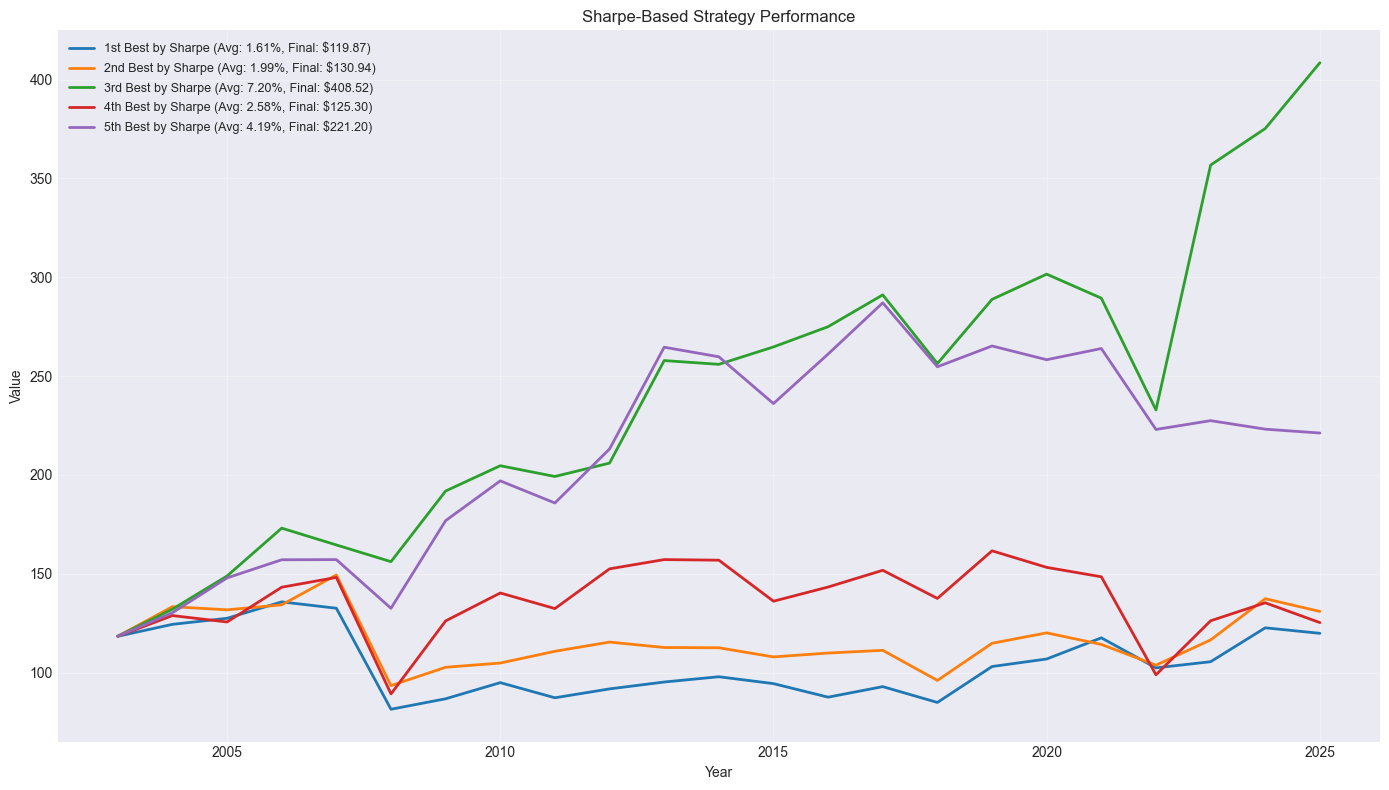

    Year       AGTHX       DODIX       FAGIX       HCAIX       PRFDX  \
0   2003  132.860000  101.170000  128.340000  129.890000  122.080000   
1   2004  148.231902  100.542746  134.872506  141.372276  134.361248   
2   2005  167.072177   98.190046  133.281010  160.471670  130.975345   
3   2006  177.948575   98.425702  141.557761  163.536679  149.311893   
4   2007  184.123391   97.953258  138.216998  182.883069  141.980679   
5   2008  110.879106   92.311151   86.938492  114.393359   86.295857   
6   2009  147.968167  101.468417  137.258491  161.740771  106.048978   
7   2010  164.806944  103.578960  150.160789  179.855737  119.686877   
8   2011  155.544794  104.127929  138.057829  180.251420  116.503206   
9   2012  185.969356  108.511714  151.269964  207.613585  133.629177   
10  2013  232.796440  105.929136  157.003095  275.835409  165.913986   
11  2014  231.073746  107.888825  154.129939  283.558801  165.714890   
12  2015  223.540742  104.047982  145.683618  293.313224  143.79

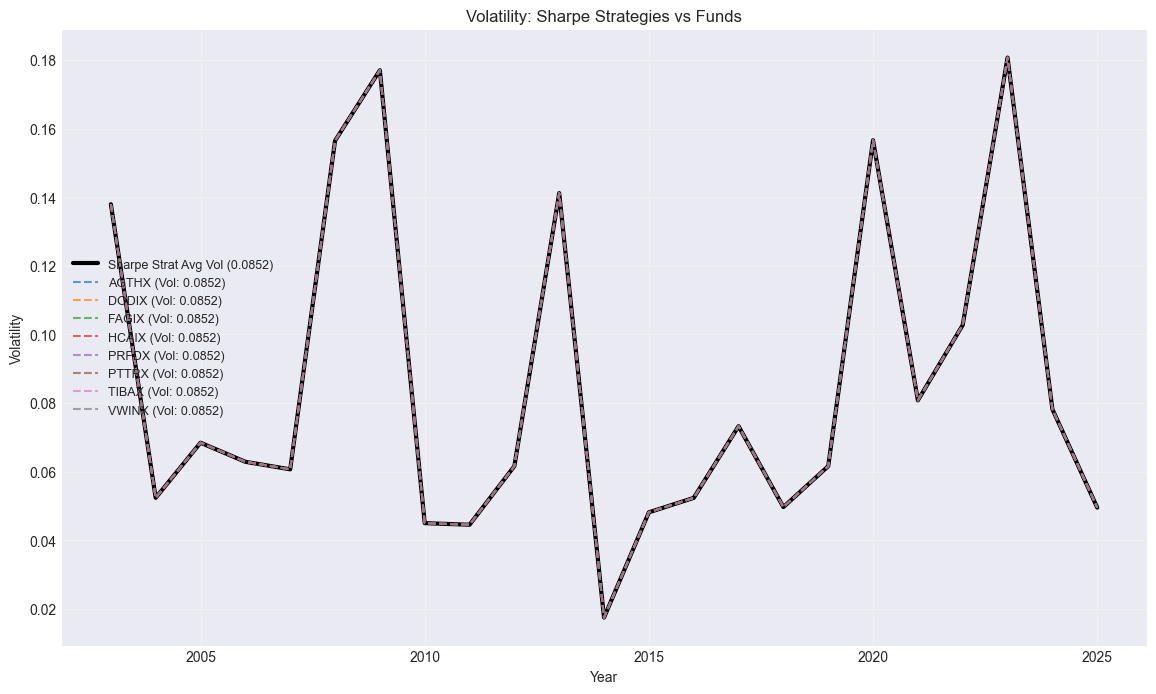

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to convert string percentages to float values
def convert_percentage(x):
    if isinstance(x, str) and '%' in x:
        return float(x.strip('%')) / 100
    return float(x)

# === START: Use df_calc directly instead of random generation ===
# Copy original DataFrame and convert columns
df_calc = df.copy()
df_calc['Annual_Return_Float'] = df_calc['Annual_Return'].apply(convert_percentage)
df_calc['Sharpe_Ratio'] = df_calc['Sharpe_Ratio'].astype(float)
# Prepare years and funds list for loops
df_extended = df_calc.copy()
years = sorted(df_extended['Year'].unique())
funds = sorted(df_extended['Fund'].unique())
# === END: Starting part replaced ===

# Calculate ranks for each year
df_extended = df_extended.assign(
    Return_Rank=df_extended.groupby('Year')['Annual_Return_Float']
                         .rank(ascending=False, method='first'),
    Sharpe_Rank=df_extended.groupby('Year')['Sharpe_Ratio']
                         .rank(ascending=False, method='first')
)

# Print first few rows to verify data format
print(df_extended.head())

# Function to implement strategy based on rank

def implement_strategy(data, start_amount=100, rank_column='Return_Rank', target_rank=1):
    """
    Invest in the fund with `target_rank` from the previous year by `rank_column`.
    """
    yrs = sorted(data['Year'].unique())
    perf = []
    amt = start_amount
    label = f"{target_rank}{'st' if target_rank==1 else 'nd' if target_rank==2 else 'rd' if target_rank==3 else 'th'} Best by {'Returns' if rank_column=='Return_Rank' else 'Sharpe'}"

    # First year: equal-weighted
    first = yrs[0]
    r0 = data.loc[data['Year']==first, 'Annual_Return_Float'].mean()
    amt *= (1 + r0)
    perf.append({'Year': first, 'Strategy': label, 'Amount': amt,
                 'Return': r0, 'Volatility': data.loc[data['Year']==first, 'Annual_Return_Float'].std()})

    for i in range(1, len(yrs)):
        yr = yrs[i]
        prev = yrs[i-1]
        ranked = data.loc[data['Year']==prev].sort_values(rank_column)
        if len(ranked) >= target_rank:
            f = ranked.iloc[target_rank-1]['Fund']
            row = data[(data['Year']==yr) & (data['Fund']==f)]
            if not row.empty:
                ret = row['Annual_Return_Float'].iloc[0]
                amt *= (1 + ret)
            else:
                ret = 0
        else:
            ret = 0
        vol = data.loc[data['Year']==yr, 'Annual_Return_Float'].std()
        perf.append({'Year': yr, 'Strategy': label, 'Amount': amt,
                     'Return': ret, 'Volatility': vol})
    return pd.DataFrame(perf)

# Run return-based strategies
return_strategies = [implement_strategy(df_extended, 100, 'Return_Rank', r) for r in range(1, 6)]
return_strategy_df = pd.concat(return_strategies)

# Run Sharpe-based strategies
sharpe_strategies = [implement_strategy(df_extended, 100, 'Sharpe_Rank', r) for r in range(1, 6)]
sharpe_strategy_df = pd.concat(sharpe_strategies)

# Individual fund performance
fund_perf = []
for fund in funds:
    df_f = df_extended[df_extended['Fund']==fund]
    val = 100
    for yr in years:
        row = df_f[df_f['Year']==yr]
        if not row.empty:
            r = row['Annual_Return_Float'].iloc[0]
            val *= (1 + r)
            vol = df_extended.loc[df_extended['Year']==yr, 'Annual_Return_Float'].std()
            fund_perf.append({'Year': yr, 'Fund': fund, 'Amount': val,
                              'Return': r, 'Volatility': vol})
fund_performance_df = pd.DataFrame(fund_perf)

# Compute summary metrics
fund_avg_returns = fund_performance_df.groupby('Fund')['Return'].mean()
fund_final_values = {
    fund: fund_performance_df[(fund_performance_df['Fund']==fund) & (fund_performance_df['Year']==years[-1])]['Amount'].values[0]
    for fund in funds if not fund_performance_df[(fund_performance_df['Fund']==fund) & (fund_performance_df['Year']==years[-1])].empty
}
return_strategy_avg_returns = return_strategy_df.groupby('Strategy')['Return'].mean()
fund_avg_sharpe = df_extended.groupby('Fund')['Sharpe_Ratio'].mean()

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Fund performance plot
plt.figure(figsize=(14, 8))
for fund in funds:
    fp = fund_performance_df[fund_performance_df['Fund']==fund]
    avg_r = fund_avg_returns[fund]
    fv = fund_final_values.get(fund, 0)
    lbl = f"{fund} (Avg: {avg_r*100:.2f}%, Final: ${fv:.2f})"
    plt.plot(fp['Year'], fp['Amount'], label=lbl, linewidth=2)
plt.title('Fund Performance Over Years (Initial $100)')
plt.xlabel('Year')
plt.ylabel('Portfolio Value ($)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 2. Return strategies plot
plt.figure(figsize=(14, 8))
for strat in return_strategy_df['Strategy'].unique():
    sd = return_strategy_df[return_strategy_df['Strategy']==strat]
    avg_r = return_strategy_avg_returns[strat]
    fv = sd[sd['Year']==years[-1]]['Amount'].iloc[0]
    lbl = f"{strat} (Avg: {avg_r*100:.2f}%, Final: ${fv:.2f})"
    plt.plot(sd['Year'], sd['Amount'], label=lbl, linewidth=2)
plt.title('Return-Based Strategy Performance')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 3. Volatility comparison (returns)
plt.figure(figsize=(14, 8))
ret_vol = return_strategy_df.groupby('Year')['Volatility'].mean()
avg_ret_vol = ret_vol.mean()
plt.plot(ret_vol.index, ret_vol.values, label=f'Return Strat Avg Vol ({avg_ret_vol:.4f})', linewidth=3, color='black')
fund_avg_vol = fund_performance_df.groupby('Fund')['Volatility'].mean()
for fund in funds:
    fdf = fund_performance_df[fund_performance_df['Fund']==fund]
    v = fund_avg_vol[fund]
    plt.plot(fdf['Year'], fdf['Volatility'], label=f"{fund} (Vol: {v:.4f})", linestyle='--', alpha=0.7)
plt.title('Volatility: Return Strategies vs Funds')
plt.xlabel('Year')
plt.ylabel('Volatility')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 4. Sharpe ratio over years
plt.figure(figsize=(14, 8))
for fund in funds:
    fdf = df_extended[df_extended['Fund']==fund]
    avg_s = fund_avg_sharpe[fund]
    plt.plot(fdf['Year'], fdf['Sharpe_Ratio'], label=f"{fund} (Avg Sharpe: {avg_s:.2f})", linewidth=2)
plt.title('Fund Sharpe Ratio Over Years')
plt.xlabel('Year')
plt.ylabel('Sharpe')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 5. Sharpe strategies plot
plt.figure(figsize=(14, 8))
sh_avg_ret = sharpe_strategy_df.groupby('Strategy')['Return'].mean()
for strat in sharpe_strategy_df['Strategy'].unique():
    sd = sharpe_strategy_df[sharpe_strategy_df['Strategy']==strat]
    avg_r = sh_avg_ret[strat]
    fv = sd[sd['Year']==years[-1]]['Amount'].iloc[0]
    lbl = f"{strat} (Avg: {avg_r*100:.2f}%, Final: ${fv:.2f})"
    plt.plot(sd['Year'], sd['Amount'], label=lbl, linewidth=2)
plt.title('Sharpe-Based Strategy Performance')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 6. Volatility comparison (Sharpe)
plt.figure(figsize=(14, 8))
sh_vol = sharpe_strategy_df.groupby('Year')['Volatility'].mean()
avg_sh_vol = sh_vol.mean()
plt.plot(sh_vol.index, sh_vol.values, label=f"Sharpe Strat Avg Vol ({avg_sh_vol:.4f})", linewidth=3, color='black')
for fund in funds:
    fdf = fund_performance_df[fund_performance_df['Fund']==fund]
    v = fund_avg_vol[fund]
    plt.plot(fdf['Year'], fdf['Volatility'], label=f"{fund} (Vol: {v:.4f})", linestyle='--', alpha=0.7)
plt.title('Volatility: Sharpe Strategies vs Funds')
plt.xlabel('Year')
plt.ylabel('Volatility')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

# === Create Final Summary Table ===

# 1) Select only the first 10 funds
funds_to_show = funds[:10]

# 2) Pivot Fund Performance: one column per fund’s final Amount
fund_pivot = (
    fund_performance_df
      .pivot(index='Year', columns='Fund', values='Amount')
      .loc[:, funds_to_show]                     # keep only first 10 funds
      .reset_index()
)

# 3) Pivot Return-based Strategies (1st–5th best by Returns)
#    we know those Strategies all contain "Best by Returns"
return_pivot = (
    return_strategy_df
      .pivot(index='Year', columns='Strategy', values='Amount')
      .filter(like='Best by Returns')           # pick only the 5 return-based strategies
      .reset_index()
)

# 4) Merge Funds and Return-strategies on Year
final_table = fund_pivot.merge(return_pivot, on='Year', how='left')

# 5) Rename the strategy columns to "1st Best Strategy" … "5th Best Strategy"
strat_cols = [c for c in final_table.columns if 'Best by Returns' in c]
new_names = {}
for i, col in enumerate(sorted(strat_cols), start=1):
    suffix = 'st' if i==1 else 'nd' if i==2 else 'rd' if i==3 else 'th'
    new_names[col] = f"{i}{suffix} Best Strategy"
final_table.rename(columns=new_names, inplace=True)

# 6) Show the result
print(final_table)


In [10]:
df

,Year,Fund,Annual_Return,Sharpe_Ratio
0,2003,FAGIX,28.34%,5.67
1,2003,HCAIX,29.89%,1.54
2,2003,PTTRX,0.37%,0.08
3,2003,TIBAX,27.33%,3.18
4,2004,FAGIX,5.09%,1.40
...,...,...,...,...
179,2024,VWINX,-0.72%,-0.09
180,2025,AGTHX,-4.70%,-0.15
181,2025,DODIX,2.10%,0.33
182,2025,PRFDX,-0.87%,-0.04


## For Balanced Funds

In [11]:
import pandas as pd
df1=pd.read_csv("mutual_fund_balanced_1.csv")
df2=pd.read_csv("mutual_fund_balanced_2.csv")
df=pd.concat([df1, df2], ignore_index=True)
df=df.drop(columns=['Return_Rank','Sharpe_Rank'], axis=1)

   Year   Fund Annual_Return  Sharpe_Ratio  Annual_Return_Float  Return_Rank  \
0  2003  DODBX        20.23%          1.88               0.2023          4.0   
1  2003  GLRBX        16.08%          2.52               0.1608          7.0   
2  2003  JABAX        11.52%          1.48               0.1152          9.0   
3  2003  OAKBX        22.40%          2.58               0.2240          3.0   
4  2003  TRRIX        12.93%          2.12               0.1293          8.0   

   Sharpe_Rank  
0          7.0  
1          2.0  
2          9.0  
3          1.0  
4          5.0  


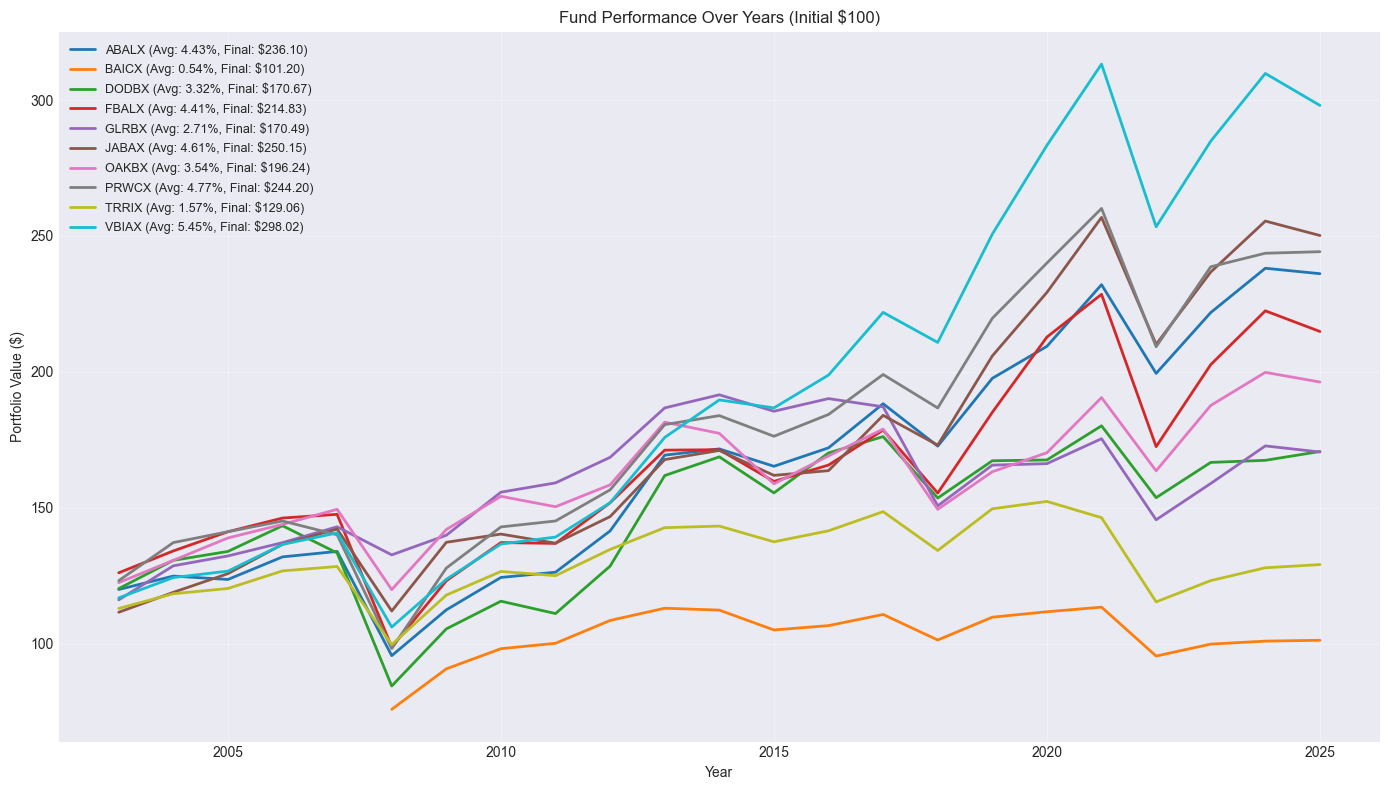

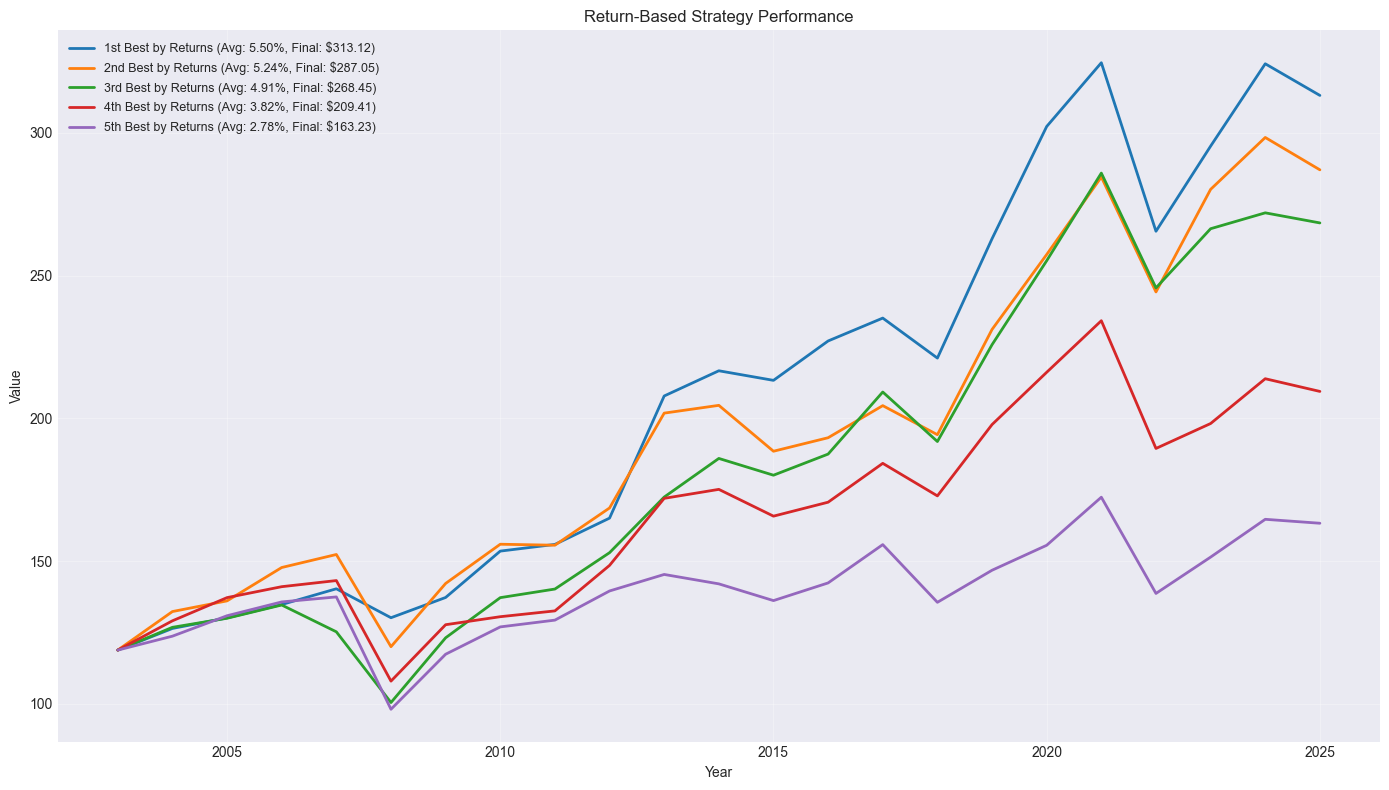

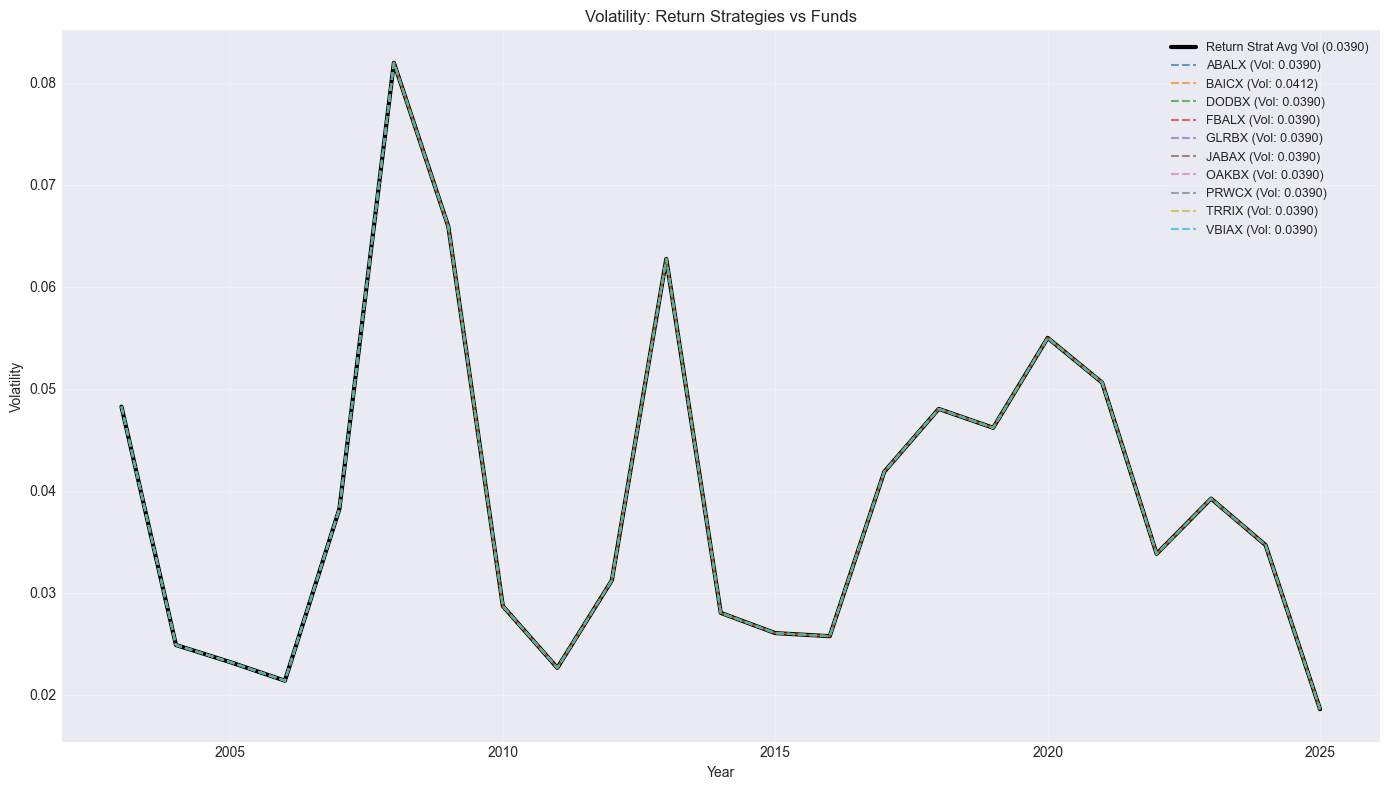

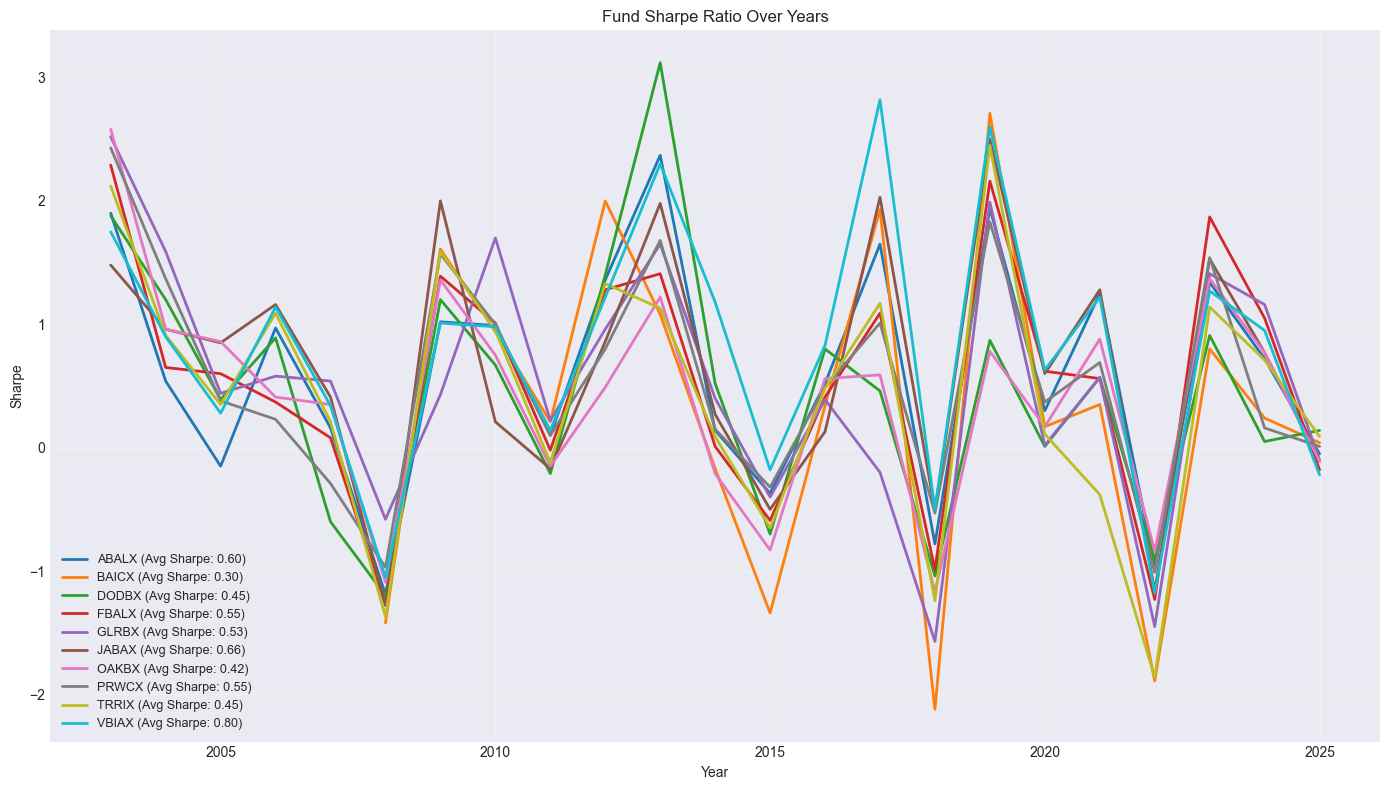

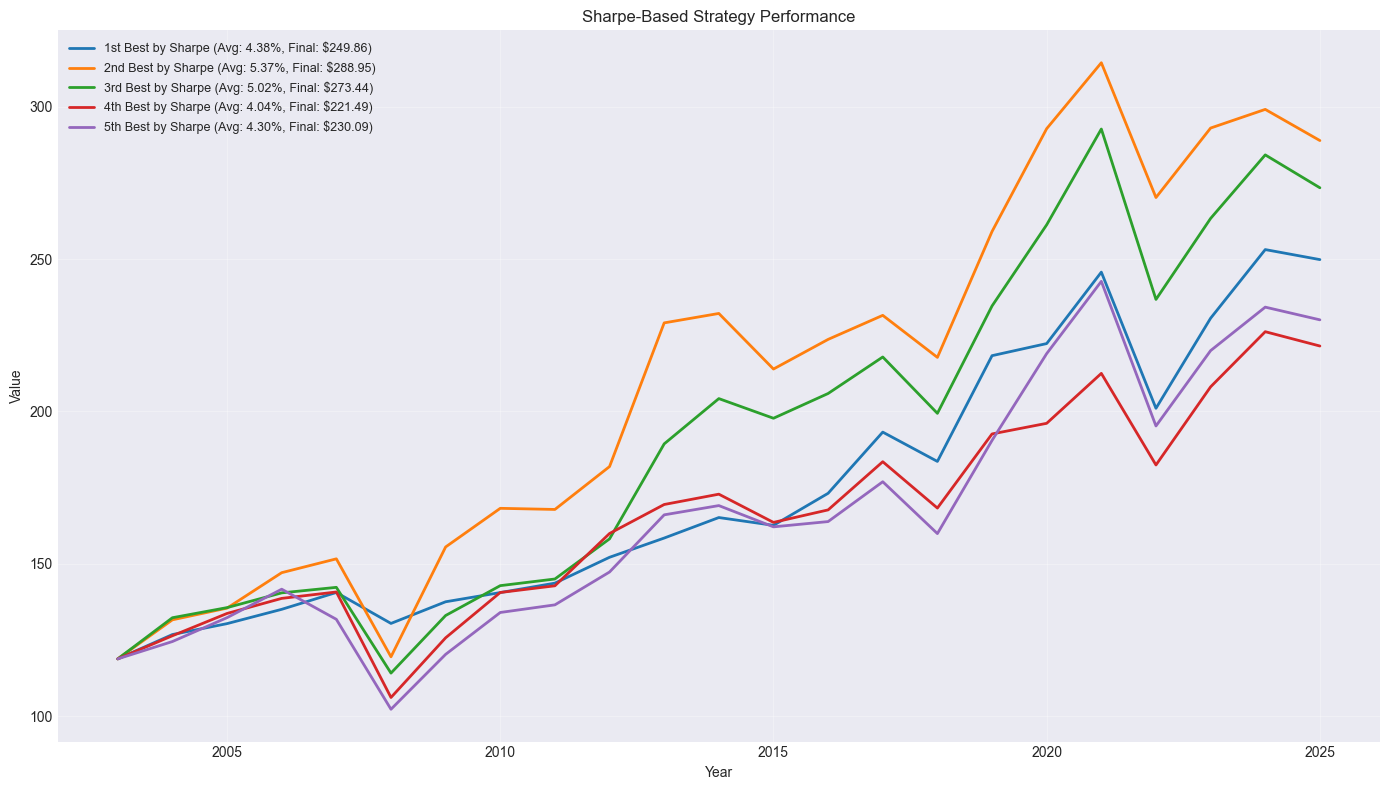

    Year       ABALX       BAICX       DODBX       FBALX       GLRBX  \
0   2003  119.900000         NaN  120.230000  126.030000  116.080000   
1   2004  124.827890         NaN  130.617872  134.083317  128.605032   
2   2005  123.579611         NaN  133.896381  141.149508  132.244554   
3   2006  131.896519         NaN  143.349465  146.188545  137.137603   
4   2007  133.901346         NaN  133.343672  147.548099  142.965951   
5   2008   95.552001   75.800000   84.379876   98.709678  132.629513   
6   2009  112.397818   90.702280  105.398903  123.090969  139.857821   
7   2010  124.323227   98.103586  115.590977  137.160266  155.703712   
8   2011  126.262669  100.104899  111.036692  136.858514  159.129194   
9   2012  141.452068  108.503700  128.502764  151.830835  168.533729   
10  2013  169.332271  113.006604  161.823531  171.174083  186.718519   
11  2014  171.618256  112.305963  168.701031  171.328140  191.535857   
12  2015  165.234057  105.006075  155.441130  159.660694  185.48

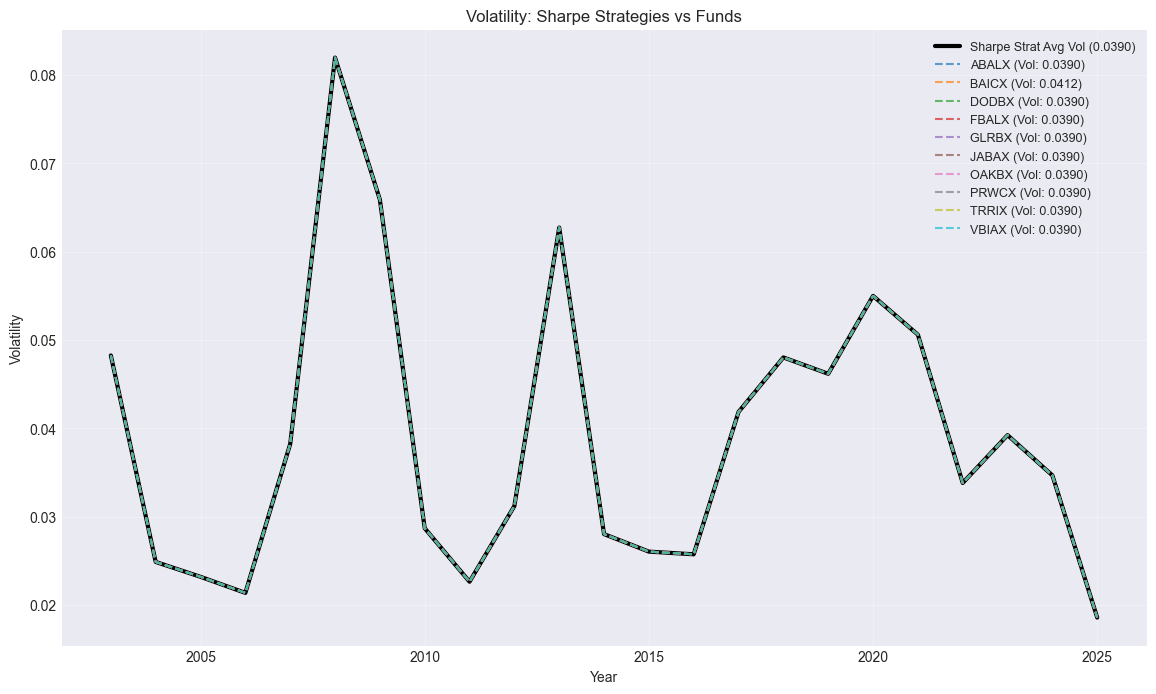

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to convert string percentages to float values
def convert_percentage(x):
    if isinstance(x, str) and '%' in x:
        return float(x.strip('%')) / 100
    return float(x)

# === START: Use df_calc directly instead of random generation ===
# Copy original DataFrame and convert columns
df_calc = df.copy()
df_calc['Annual_Return_Float'] = df_calc['Annual_Return'].apply(convert_percentage)
df_calc['Sharpe_Ratio'] = df_calc['Sharpe_Ratio'].astype(float)
# Prepare years and funds list for loops
df_extended = df_calc.copy()
years = sorted(df_extended['Year'].unique())
funds = sorted(df_extended['Fund'].unique())
# === END: Starting part replaced ===

# Calculate ranks for each year
df_extended = df_extended.assign(
    Return_Rank=df_extended.groupby('Year')['Annual_Return_Float']
                         .rank(ascending=False, method='first'),
    Sharpe_Rank=df_extended.groupby('Year')['Sharpe_Ratio']
                         .rank(ascending=False, method='first')
)

# Print first few rows to verify data format
print(df_extended.head())

# Function to implement strategy based on rank

def implement_strategy(data, start_amount=100, rank_column='Return_Rank', target_rank=1):
    """
    Invest in the fund with `target_rank` from the previous year by `rank_column`.
    """
    yrs = sorted(data['Year'].unique())
    perf = []
    amt = start_amount
    label = f"{target_rank}{'st' if target_rank==1 else 'nd' if target_rank==2 else 'rd' if target_rank==3 else 'th'} Best by {'Returns' if rank_column=='Return_Rank' else 'Sharpe'}"

    # First year: equal-weighted
    first = yrs[0]
    r0 = data.loc[data['Year']==first, 'Annual_Return_Float'].mean()
    amt *= (1 + r0)
    perf.append({'Year': first, 'Strategy': label, 'Amount': amt,
                 'Return': r0, 'Volatility': data.loc[data['Year']==first, 'Annual_Return_Float'].std()})

    for i in range(1, len(yrs)):
        yr = yrs[i]
        prev = yrs[i-1]
        ranked = data.loc[data['Year']==prev].sort_values(rank_column)
        if len(ranked) >= target_rank:
            f = ranked.iloc[target_rank-1]['Fund']
            row = data[(data['Year']==yr) & (data['Fund']==f)]
            if not row.empty:
                ret = row['Annual_Return_Float'].iloc[0]
                amt *= (1 + ret)
            else:
                ret = 0
        else:
            ret = 0
        vol = data.loc[data['Year']==yr, 'Annual_Return_Float'].std()
        perf.append({'Year': yr, 'Strategy': label, 'Amount': amt,
                     'Return': ret, 'Volatility': vol})
    return pd.DataFrame(perf)

# Run return-based strategies
return_strategies = [implement_strategy(df_extended, 100, 'Return_Rank', r) for r in range(1, 6)]
return_strategy_df = pd.concat(return_strategies)

# Run Sharpe-based strategies
sharpe_strategies = [implement_strategy(df_extended, 100, 'Sharpe_Rank', r) for r in range(1, 6)]
sharpe_strategy_df = pd.concat(sharpe_strategies)

# Individual fund performance
fund_perf = []
for fund in funds:
    df_f = df_extended[df_extended['Fund']==fund]
    val = 100
    for yr in years:
        row = df_f[df_f['Year']==yr]
        if not row.empty:
            r = row['Annual_Return_Float'].iloc[0]
            val *= (1 + r)
            vol = df_extended.loc[df_extended['Year']==yr, 'Annual_Return_Float'].std()
            fund_perf.append({'Year': yr, 'Fund': fund, 'Amount': val,
                              'Return': r, 'Volatility': vol})
fund_performance_df = pd.DataFrame(fund_perf)

# Compute summary metrics
fund_avg_returns = fund_performance_df.groupby('Fund')['Return'].mean()
fund_final_values = {
    fund: fund_performance_df[(fund_performance_df['Fund']==fund) & (fund_performance_df['Year']==years[-1])]['Amount'].values[0]
    for fund in funds if not fund_performance_df[(fund_performance_df['Fund']==fund) & (fund_performance_df['Year']==years[-1])].empty
}
return_strategy_avg_returns = return_strategy_df.groupby('Strategy')['Return'].mean()
fund_avg_sharpe = df_extended.groupby('Fund')['Sharpe_Ratio'].mean()

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Fund performance plot
plt.figure(figsize=(14, 8))
for fund in funds:
    fp = fund_performance_df[fund_performance_df['Fund']==fund]
    avg_r = fund_avg_returns[fund]
    fv = fund_final_values.get(fund, 0)
    lbl = f"{fund} (Avg: {avg_r*100:.2f}%, Final: ${fv:.2f})"
    plt.plot(fp['Year'], fp['Amount'], label=lbl, linewidth=2)
plt.title('Fund Performance Over Years (Initial $100)')
plt.xlabel('Year')
plt.ylabel('Portfolio Value ($)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 2. Return strategies plot
plt.figure(figsize=(14, 8))
for strat in return_strategy_df['Strategy'].unique():
    sd = return_strategy_df[return_strategy_df['Strategy']==strat]
    avg_r = return_strategy_avg_returns[strat]
    fv = sd[sd['Year']==years[-1]]['Amount'].iloc[0]
    lbl = f"{strat} (Avg: {avg_r*100:.2f}%, Final: ${fv:.2f})"
    plt.plot(sd['Year'], sd['Amount'], label=lbl, linewidth=2)
plt.title('Return-Based Strategy Performance')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 3. Volatility comparison (returns)
plt.figure(figsize=(14, 8))
ret_vol = return_strategy_df.groupby('Year')['Volatility'].mean()
avg_ret_vol = ret_vol.mean()
plt.plot(ret_vol.index, ret_vol.values, label=f'Return Strat Avg Vol ({avg_ret_vol:.4f})', linewidth=3, color='black')
fund_avg_vol = fund_performance_df.groupby('Fund')['Volatility'].mean()
for fund in funds:
    fdf = fund_performance_df[fund_performance_df['Fund']==fund]
    v = fund_avg_vol[fund]
    plt.plot(fdf['Year'], fdf['Volatility'], label=f"{fund} (Vol: {v:.4f})", linestyle='--', alpha=0.7)
plt.title('Volatility: Return Strategies vs Funds')
plt.xlabel('Year')
plt.ylabel('Volatility')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 4. Sharpe ratio over years
plt.figure(figsize=(14, 8))
for fund in funds:
    fdf = df_extended[df_extended['Fund']==fund]
    avg_s = fund_avg_sharpe[fund]
    plt.plot(fdf['Year'], fdf['Sharpe_Ratio'], label=f"{fund} (Avg Sharpe: {avg_s:.2f})", linewidth=2)
plt.title('Fund Sharpe Ratio Over Years')
plt.xlabel('Year')
plt.ylabel('Sharpe')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 5. Sharpe strategies plot
plt.figure(figsize=(14, 8))
sh_avg_ret = sharpe_strategy_df.groupby('Strategy')['Return'].mean()
for strat in sharpe_strategy_df['Strategy'].unique():
    sd = sharpe_strategy_df[sharpe_strategy_df['Strategy']==strat]
    avg_r = sh_avg_ret[strat]
    fv = sd[sd['Year']==years[-1]]['Amount'].iloc[0]
    lbl = f"{strat} (Avg: {avg_r*100:.2f}%, Final: ${fv:.2f})"
    plt.plot(sd['Year'], sd['Amount'], label=lbl, linewidth=2)
plt.title('Sharpe-Based Strategy Performance')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 6. Volatility comparison (Sharpe)
plt.figure(figsize=(14, 8))
sh_vol = sharpe_strategy_df.groupby('Year')['Volatility'].mean()
avg_sh_vol = sh_vol.mean()
plt.plot(sh_vol.index, sh_vol.values, label=f"Sharpe Strat Avg Vol ({avg_sh_vol:.4f})", linewidth=3, color='black')
for fund in funds:
    fdf = fund_performance_df[fund_performance_df['Fund']==fund]
    v = fund_avg_vol[fund]
    plt.plot(fdf['Year'], fdf['Volatility'], label=f"{fund} (Vol: {v:.4f})", linestyle='--', alpha=0.7)
plt.title('Volatility: Sharpe Strategies vs Funds')
plt.xlabel('Year')
plt.ylabel('Volatility')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

# === Create Final Summary Table ===

# 1) Select only the first 10 funds
funds_to_show = funds[:10]

# 2) Pivot Fund Performance: one column per fund’s final Amount
fund_pivot = (
    fund_performance_df
      .pivot(index='Year', columns='Fund', values='Amount')
      .loc[:, funds_to_show]                     # keep only first 10 funds
      .reset_index()
)

# 3) Pivot Return-based Strategies (1st–5th best by Returns)
#    we know those Strategies all contain "Best by Returns"
return_pivot = (
    return_strategy_df
      .pivot(index='Year', columns='Strategy', values='Amount')
      .filter(like='Best by Returns')           # pick only the 5 return-based strategies
      .reset_index()
)

# 4) Merge Funds and Return-strategies on Year
final_table = fund_pivot.merge(return_pivot, on='Year', how='left')

# 5) Rename the strategy columns to "1st Best Strategy" … "5th Best Strategy"
strat_cols = [c for c in final_table.columns if 'Best by Returns' in c]
new_names = {}
for i, col in enumerate(sorted(strat_cols), start=1):
    suffix = 'st' if i==1 else 'nd' if i==2 else 'rd' if i==3 else 'th'
    new_names[col] = f"{i}{suffix} Best Strategy"
final_table.rename(columns=new_names, inplace=True)

# 6) Show the result
print(final_table)
